# Forecasting Air Quality in Kolkata
### A Time Series Model Comparison Under Extreme Pollution Events

**Student:** T. Kugashanth (22CDS0446)
**Department:** Data Science, Sabaragamuwa University of Sri Lanka
**Supervisor:** Prof. S. Vasanthapriyan, Ph.D, SMIEEE
**Capstone Project II — August 2026**

This notebook builds and compares four forecasting models — **SARIMA, Prophet, XGBoost, and LSTM** — for hourly PM2.5 in Kolkata, and evaluates each one separately on **normal** days versus **extreme pollution event** days (Diwali, COVID-19 lockdown, cyclones, heatwaves).

Work through the cells top to bottom. Markdown cells explain *why* a step matters; code cells directly below do the work.

## Step 0 — Set Up Your Environment
**Goal:** install every library needed and fix a random seed so results are reproducible.

In [8]:
!pip install -q pandas numpy matplotlib seaborn statsmodels prophet
!pip install -q xgboost tensorflow scikit-learn huggingface_hub
!pip install -q pmdarima ruptures


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import huggingface_hub
warnings.filterwarnings('ignore')

# Reproducibility: always fix a random seed so results don't change every run
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [10]:
import os
for folder in ['data', 'figures', 'models', 'results']:
    os.makedirs(folder, exist_ok=True)

## Step 1 — Collect the Data
**Goal:** download the Kolkata air-quality dataset and load it correctly, with the required ethics disclosure.

### Data Source & Ethics Disclosure
- **Dataset:** `neuralsorcerer/air-quality` (Hugging Face, CC0-1.0 license)
- **Coverage:** Kolkata, India | Jan 2015 – Dec 2024 | hourly | 87,672 rows
- **NOTE:** This dataset is **synthetically generated** and calibrated to published CPCB (Central Pollution Control Board) and IMD (India Meteorological Department) statistics. It is **not** raw sensor data. It is used here as a realistic, event-rich benchmark for comparing forecasting methodology, not as a factual historical record of Kolkata's air quality. This disclosure is repeated in the final report.

In [11]:
# from huggingface_hub import hf_hub_download

# csv_path = hf_hub_download(
#     repo_id='data/air-quality',
#     filename='air_quality.csv',
#     repo_type='dataset'
# )


# print('Downloaded to:', csv_path)

# # Backup plan if the download above fails:
# # 1) Visit https://huggingface.co/datasets/neuralsorcerer/air-quality
# # 2) Download air_quality.csv manually and upload it via the Colab file panel
# # 3) Then set: csv_path = 'air_quality.csv'

import pandas as pd
csv_path='data/air_quality.csv'
df = pd.read_csv('data/air_quality.csv')
df

,datetime,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain
0,2015-01-01 00:00:00,150.849670,257.310990,32.664554,1.204211,4.816183,1.364593,17.926895,42.058440,0.100000,1.085120
1,2015-01-01 01:00:00,132.370120,254.495468,31.878915,0.860830,1.937702,1.000000,16.655569,37.960572,0.100000,0.000000
2,2015-01-01 02:00:00,157.994518,256.419390,28.320158,0.074682,4.197653,2.516940,17.283748,37.412200,0.100000,0.000000
3,2015-01-01 03:00:00,173.358215,269.406690,33.000651,2.563948,7.383085,1.000000,34.383131,17.713272,0.100000,0.393723
4,2015-01-01 04:00:00,201.753827,335.956343,30.997890,1.326620,2.140768,1.000000,18.198381,39.903303,0.100000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
87667,2024-12-31 19:00:00,63.412273,134.838002,29.711573,0.123954,6.032440,6.302620,19.316101,39.965851,0.200606,0.000000
87668,2024-12-31 20:00:00,43.645258,139.497741,37.154593,2.120450,5.908898,1.000000,10.420467,50.819212,0.100000,0.000000
87669,2024-12-31 21:00:00,51.564349,151.465692,22.099836,0.050000,3.892448,3.811726,10.000000,51.816186,0.100000,1.777392
87670,2024-12-31 22:00:00,79.195221,178.872875,9.487977,0.168492,6.070504,4.539772,15.624267,39.341213,0.100000,2.110191


In [12]:
df = pd.read_csv(csv_path, parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)
df.head()

,datetime,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain
0,2015-01-01 00:00:00,150.849670,257.310990,32.664554,1.204211,4.816183,1.364593,17.926895,42.058440,0.1,1.085120
1,2015-01-01 01:00:00,132.370120,254.495468,31.878915,0.860830,1.937702,1.000000,16.655569,37.960572,0.1,0.000000
2,2015-01-01 02:00:00,157.994518,256.419390,28.320158,0.074682,4.197653,2.516940,17.283748,37.412200,0.1,0.000000
3,2015-01-01 03:00:00,173.358215,269.406690,33.000651,2.563948,7.383085,1.000000,34.383131,17.713272,0.1,0.393723
4,2015-01-01 04:00:00,201.753827,335.956343,30.997890,1.326620,2.140768,1.000000,18.198381,39.903303,0.1,0.000000


## Step 2 — Understand the Data
**Goal:** get a first honest look at the dataset before changing anything.

In [13]:
print(df.shape)
df.info()

(87672, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87672 entries, 0 to 87671
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  87672 non-null  datetime64[ns]
 1   pm25      87672 non-null  float64       
 2   pm10      87672 non-null  float64       
 3   no2       87672 non-null  float64       
 4   co        87672 non-null  float64       
 5   so2       87672 non-null  float64       
 6   o3        87672 non-null  float64       
 7   temp      87672 non-null  float64       
 8   rh        87672 non-null  float64       
 9   wind      87672 non-null  float64       
 10  rain      87672 non-null  float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 7.4 MB


In [14]:
df.describe()

,datetime,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain
count,87672,87672.000000,87672.000000,87672.000000,87672.000000,87672.000000,87672.000000,87672.000000,87672.000000,87672.000000,87672.000000
mean,2020-01-01 11:30:00,57.828326,98.981629,20.380443,0.999363,4.093981,12.365964,26.967928,59.644105,1.566229,14.651464
min,2015-01-01 00:00:00,15.000000,30.000000,5.000000,0.050000,0.050000,1.000000,10.000000,5.000000,0.100000,0.000000
25%,2017-07-02 05:45:00,20.735777,39.712592,11.487912,0.050000,2.112934,1.000000,20.158294,39.763042,0.100000,0.000000
50%,2020-01-01 11:30:00,47.379220,77.363812,18.405700,0.667111,3.789012,4.964779,26.484439,58.792463,1.168418,0.273485
75%,2022-07-02 17:15:00,81.719948,140.916957,26.568068,1.665556,5.617663,12.306806,33.506717,78.581882,2.546975,1.914113
max,2024-12-31 23:00:00,926.149477,989.887003,84.928413,6.742515,38.134694,112.169819,45.000000,100.000000,29.946471,351.872020
std,NaN,46.538527,71.486695,12.095623,1.060623,2.791388,17.592039,9.144992,23.614732,1.613901,50.675309


In [15]:
df.isna().sum()

datetime    0
pm25        0
pm10        0
no2         0
co          0
so2         0
o3          0
temp        0
rh          0
wind        0
rain        0
dtype: int64

### 2.1 Sanity-check the value ranges

In [16]:
cols = ['pm25','pm10','no2','co','so2','o3','temp','rh','wind','rain']
df[cols].agg(['min','max','mean']).T

,min,max,mean
pm25,15.00,926.149477,57.828326
pm10,30.00,989.887003,98.981629
no2,5.00,84.928413,20.380443
co,0.05,6.742515,0.999363
so2,0.05,38.134694,4.093981
o3,1.00,112.169819,12.365964
temp,10.00,45.000000,26.967928
rh,5.00,100.000000,59.644105
wind,0.10,29.946471,1.566229
rain,0.00,351.872020,14.651464


## Step 3 — Clean the Data
**Goal:** make sure the dataset is well-formed, correctly typed, and free of duplicate timestamps.

In [17]:
# 1. Remove exact duplicate rows, if any
df = df.drop_duplicates()

# 2. Remove duplicate timestamps (keep the first occurrence)
df = df.drop_duplicates(subset='datetime', keep='first')

# 3. Confirm the hourly index has no gaps
full_range = pd.date_range(start=df['datetime'].min(),
                            end=df['datetime'].max(), freq='h')
missing_hours = full_range.difference(df['datetime'])
print('Missing hourly timestamps:', len(missing_hours))

# 4. If there ARE gaps, reindex and interpolate (time-aware fill)
df = df.set_index('datetime').reindex(full_range)
df.index.name = 'datetime'
df[cols] = df[cols].interpolate(method='time')
df = df.reset_index()

Missing hourly timestamps: 0


### 3.1 Clip physically impossible values

In [18]:
# Pollutant concentrations and rain cannot be negative
for c in ['pm25','pm10','no2','co','so2','o3','rain']:
    df[c] = df[c].clip(lower=0)

# Relative humidity is a percentage, 0-100
df['rh'] = df['rh'].clip(lower=0, upper=100)

## Step 4 — Explore the Data Visually (EDA)
**Goal:** build intuition for trend, seasonality, and correlations before modelling.

### 4.1 Long-term trend

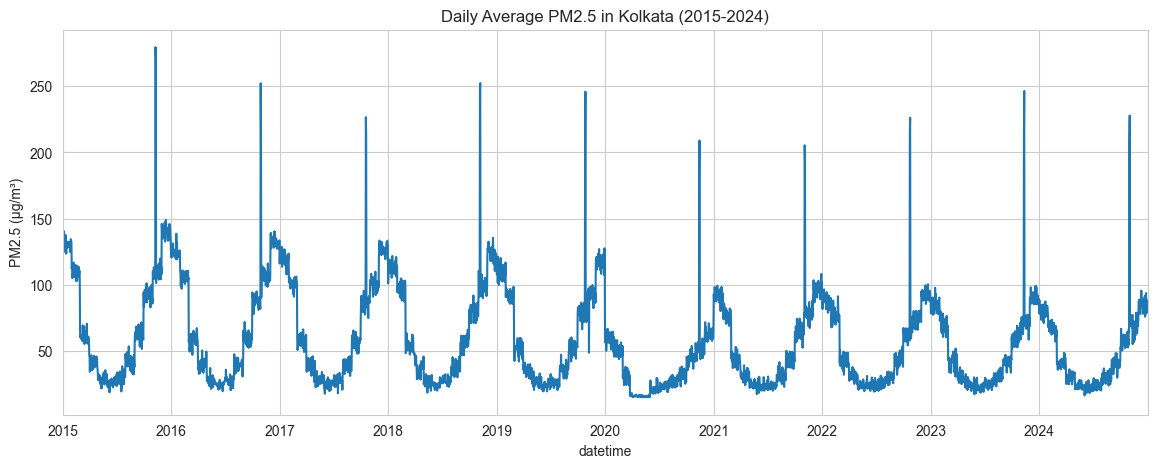

In [19]:
plt.figure(figsize=(14,5))
df.set_index('datetime')['pm25'].resample('D').mean().plot()
plt.title('Daily Average PM2.5 in Kolkata (2015-2024)')
plt.ylabel('PM2.5 (µg/m³)')
plt.savefig('figures/pm25_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Seasonality: month-of-year and hour-of-day patterns

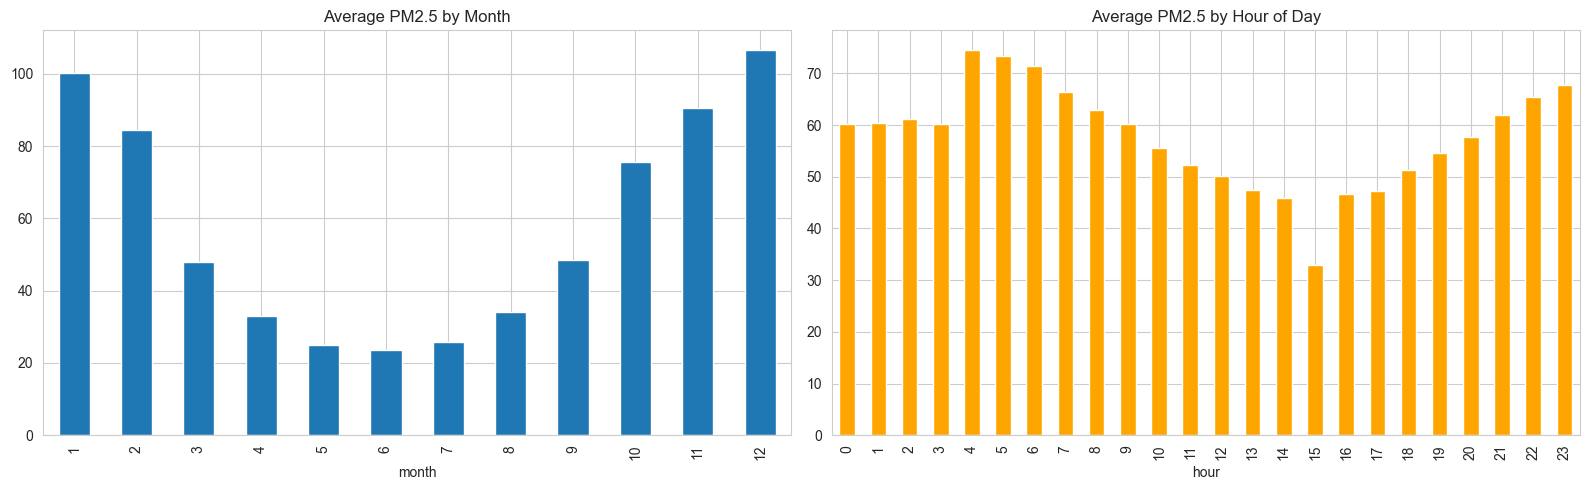

In [20]:
df['month'] = df['datetime'].dt.month
df['hour']  = df['datetime'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16,5))
df.groupby('month')['pm25'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Average PM2.5 by Month')
df.groupby('hour')['pm25'].mean().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Average PM2.5 by Hour of Day')
plt.tight_layout()
plt.savefig('figures/seasonality.png', dpi=150)
plt.show()

### 4.3 Correlation between pollutants and weather

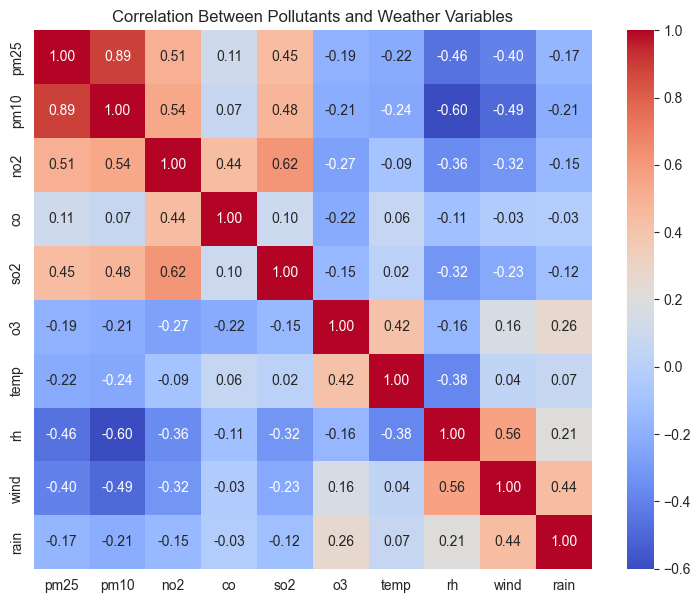

In [21]:
plt.figure(figsize=(9,7))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Pollutants and Weather Variables')
plt.savefig('figures/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Label Extreme Pollution Events
**Goal:** mark which timestamps fall inside a known extreme event (Diwali, COVID-19 lockdown, cyclones, heatwaves), so models can later be scored separately on "normal" vs. "extreme" periods.

> **Verify before finalizing:** double-check exact Diwali/cyclone dates for each year — festival dates shift on the lunar calendar.

In [22]:
event_windows = [
    # (event_name, start_date, end_date)
    ('Diwali_2015', '2015-11-09', '2015-11-13'),
    ('Diwali_2016', '2016-10-28', '2016-11-01'),
    ('Diwali_2017', '2017-10-17', '2017-10-21'),
    ('Diwali_2018', '2018-11-05', '2018-11-09'),
    ('Diwali_2019', '2019-10-25', '2019-10-29'),
    ('Diwali_2020', '2020-11-12', '2020-11-16'),
    ('Diwali_2021', '2021-11-02', '2021-11-06'),
    ('Diwali_2022', '2022-10-22', '2022-10-26'),
    ('Diwali_2023', '2023-11-10', '2023-11-14'),
    ('Diwali_2024', '2024-10-29', '2024-11-02'),
    ('COVID_Lockdown', '2020-03-25', '2020-05-31'),
    ('Cyclone_Amphan', '2020-05-18', '2020-05-22'),
    ('Cyclone_Yaas', '2021-05-24', '2021-05-28'),
    ('Heatwave_2023', '2023-04-15', '2023-04-25'),
    ('Heatwave_2024', '2024-04-20', '2024-05-05'),
]

df['event_flag'] = 'Normal'
df['event_name'] = None
for name, start, end in event_windows:
    mask = (df['datetime'] >= start) & (df['datetime'] <= end)
    df.loc[mask, 'event_flag'] = 'Extreme'
    df.loc[mask, 'event_name'] = name

df['event_flag'].value_counts()

event_flag
Normal     84394
Extreme     3278
Name: count, dtype: int64

### 5.1 Cross-check with automatic anomaly detection (optional, strengthens the project)

In [23]:
import ruptures as rpt

daily = df.set_index('datetime')['pm25'].resample('D').mean().dropna()
algo = rpt.Pelt(model='rbf').fit(daily.values)
breakpoints = algo.predict(pen=10)
print('Detected change-points:', len(breakpoints))

Detected change-points: 46


## Step 6 — Engineer Features
**Goal:** turn the raw hourly series into inputs the machine-learning models (XGBoost, LSTM) can learn from.

In [24]:
target = 'pm25'   # you can repeat the whole pipeline for pm10 and no2 too

feat = df.set_index('datetime').copy()

# Calendar features
feat['hour']       = feat.index.hour
feat['dayofweek']  = feat.index.dayofweek
feat['month']      = feat.index.month
feat['is_weekend'] = (feat['dayofweek'] >= 5).astype(int)

# Lag features: 'what was PM2.5 N hours ago'
for lag in [1, 3, 6, 24, 168]:      # 1h, 3h, 6h, 1 day, 1 week
    feat[f'{target}_lag_{lag}'] = feat[target].shift(lag)

# Rolling-window features: recent trend and volatility
feat[f'{target}_roll_mean_24'] = feat[target].shift(1).rolling(24).mean()
feat[f'{target}_roll_std_24']  = feat[target].shift(1).rolling(24).std()

# Weather features are used as-is (already in df): temp, rh, wind, rain

feat = feat.dropna()   # lag/rolling features create NaNs at the very start
feat.head()

,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain,...,event_name,dayofweek,is_weekend,pm25_lag_1,pm25_lag_3,pm25_lag_6,pm25_lag_24,pm25_lag_168,pm25_roll_mean_24,pm25_roll_std_24
datetime,,,,,,,,,,,,,,,,,,,,,
2015-11-09 00:00:00,91.677748,196.395168,32.103061,1.634592,8.197473,1.000000,10.000000,62.866788,0.1,0.000000,...,Diwali_2015,0,0,134.438138,81.304537,59.284729,122.343741,90.294314,108.084507,27.726930
2015-11-09 01:00:00,84.245822,196.628018,24.478495,0.050000,2.776151,6.583360,22.221921,45.055739,0.1,3.712105,...,Diwali_2015,0,0,91.677748,111.680134,80.238939,79.231349,111.539026,106.806757,27.747834
2015-11-09 02:00:00,117.924866,202.708128,34.370441,0.351714,2.427348,5.040469,27.695107,38.058517,0.1,1.586131,...,Diwali_2015,0,0,84.245822,134.438138,105.410820,120.392712,111.928224,107.015694,27.549338
2015-11-09 03:00:00,95.115112,199.952635,27.682938,0.082451,4.627604,2.940781,12.554328,54.458863,0.1,0.000000,...,Diwali_2015,0,0,117.924866,91.677748,81.304537,76.058612,95.719749,106.912867,27.501802
2015-11-09 04:00:00,203.485620,267.919368,29.693148,1.417629,5.103066,1.747154,24.559744,40.686111,0.1,0.000000,...,Diwali_2015,0,0,95.115112,84.245822,111.680134,147.884019,148.719166,107.706888,26.839378


## Step 7 — Split the Data: Train / Test
**Goal:** split chronologically (never randomly) and prepare separate "normal" and "extreme" test subsets.

> Time series data has order and memory — a random split would let the model "see the future" during training. Always split by date.

In [25]:
# Chronological split: last 20% of the timeline is the test set
split_date = feat.index[int(len(feat) * 0.8)]
print('Train/test split date:', split_date)

train = feat[feat.index < split_date]
test  = feat[feat.index >= split_date]

# Within the TEST set, separate normal vs extreme rows using event_flag
event_lookup = df.set_index('datetime')['event_flag']
# test = test.join(event_lookup)

test_normal  = test[test['event_flag'] == 'Normal']
test_extreme = test[test['event_flag'] == 'Extreme']

print('Train size:', len(train))
print('Test (normal) size:', len(test_normal))
print('Test (extreme) size:', len(test_extreme))

Train/test split date: 2023-04-20 20:00:00
Train size: 2622
Test (normal) size: 0
Test (extreme) size: 656


## Step 8 — Build Model 1: SARIMA
**Goal:** fit a classical statistical baseline that captures trend and repeating (seasonal) patterns.

SARIMA = Seasonal AutoRegressive Integrated Moving Average. It predicts the next value using recent past values, the recent drift, recent forecast errors, plus a repeating seasonal pattern.

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA works on the raw series (resampled to daily to keep it fast/stable)
daily_series = df.set_index('datetime')[target].resample('D').mean()
daily_train = daily_series[daily_series.index < split_date]
daily_test  = daily_series[daily_series.index >= split_date]

sarima_model = SARIMAX(
    daily_train,
    order=(1,1,1),            # (p,d,q): non-seasonal terms
    seasonal_order=(1,1,1,7), # (P,D,Q,s): weekly seasonality, s=7 days
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                              pm25   No. Observations:                 3032
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -11716.258
Date:                           Tue, 29 Sep 2026   AIC                          23442.516
Time:                                   01:28:01   BIC                          23472.572
Sample:                               01-01-2015   HQIC                         23453.324
                                    - 04-20-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4709      0.016     30.122      0.000       0.440       0.502
ma.L1         -0.8486      0.011    -74.990

In [27]:
sarima_forecast = sarima_fit.get_forecast(steps=len(daily_test))
sarima_pred = sarima_forecast.predicted_mean
sarima_pred.index = daily_test.index

> **Tip:** `order=(1,1,1)` and `seasonal_order=(1,1,1,7)` are starting points. If you have time, use `pmdarima`'s `auto_arima()` to search for better values automatically.

## Step 9 — Build Model 2: Prophet
**Goal:** fit Meta's Prophet model, designed to handle strong seasonality and irregular events with little tuning.

In [28]:
from prophet import Prophet

prophet_train = daily_train.reset_index()
prophet_train.columns = ['ds', 'y']   # Prophet requires these exact column names

# Tell Prophet about your known extreme-event dates so it can learn their effect
events_df = pd.DataFrame(event_windows, columns=['holiday','ds','ds_end'])
events_df['ds'] = pd.to_datetime(events_df['ds'])
events_df['lower_window'] = 0
events_df['upper_window'] = (pd.to_datetime(events_df['ds_end']) - events_df['ds']).dt.days

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=events_df[['holiday','ds','lower_window','upper_window']]
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(daily_test), freq='D')
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index('ds')['yhat'].loc[daily_test.index]

01:28:04 - cmdstanpy - INFO - Chain [1] start processing
01:28:11 - cmdstanpy - INFO - Chain [1] done processing


## Step 10 — Build Model 3: XGBoost
**Goal:** fit a gradient-boosted tree model on the engineered features from Step 6 — a strong ML baseline using lags, rolling stats, and weather together.

In [29]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

feature_cols = [c for c in feat.columns
                if c not in [target] and feat[c].dtype != 'object']

X_train, y_train = train[feature_cols], train[target]
X_test,  y_test  = test[feature_cols],  test[target]

xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

### 10.1 See which features matter most

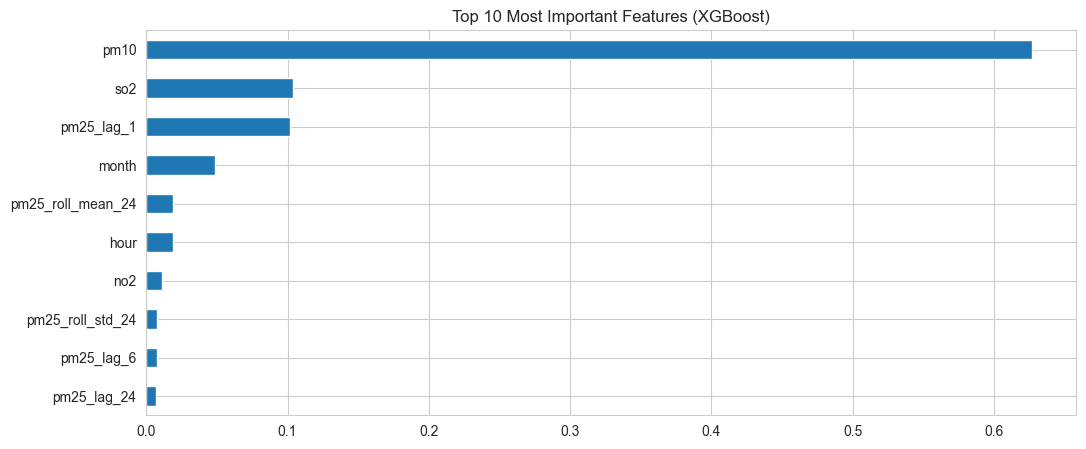

In [30]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.gca().invert_yaxis()
plt.savefig('figures/xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Build Model 4: LSTM
**Goal:** fit a Long Short-Term Memory neural network that reads a sequence of recent hours and predicts what comes next.

### 11.1 Prepare sequences and scale the data

In [31]:
from sklearn.preprocessing import MinMaxScaler

series = df.set_index('datetime')[target].values.reshape(-1, 1)
n_train = int(len(series) * 0.8)

scaler = MinMaxScaler()
scaler.fit(series[:n_train])          # fit ONLY on training data to avoid leakage
scaled = scaler.transform(series)

def make_sequences(data, window=24):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window = 24   # use the last 24 hours to predict the next hour
X_all, y_all = make_sequences(scaled, window)

X_lstm_train = X_all[:n_train-window].reshape(-1, window, 1)
y_lstm_train = y_all[:n_train-window]
X_lstm_test  = X_all[n_train-window:].reshape(-1, window, 1)
y_lstm_test  = y_all[n_train-window:]

### 11.2 Build and train the network

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - loss: 0.0013 - val_loss: 7.8294e-04
Epoch 2/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 8.8285e-04 - val_loss: 8.4855e-04
Epoch 3/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 8.4800e-04 - val_loss: 7.4333e-04
Epoch 4/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 8.4756e-04 - val_loss: 7.5865e-04
Epoch 5/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 8.5209e-04 - val_loss: 7.1565e-04
Epoch 6/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - loss: 8.2934e-04 - val_loss: 7.0713e-04
Epoch 7/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 8.3170e-04 - val_loss: 7.2151e-04
Epoch 8/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - loss: 8.0497e-04 - val_loss: 7.5252e-04
Epoch 9/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 35s 35ms/step - loss: 8.1554e-04 - val_loss: 7.2762e-04
Epoch 10/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - loss: 7.8394e-04 - val_loss: 6.9170e-04
Epoch 11/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 33

In [33]:
lstm_pred_scaled = lstm_model.predict(X_lstm_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_actual = scaler.inverse_transform(y_lstm_test.reshape(-1,1)).flatten()

548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step


> **Tip:** In Colab go to `Runtime > Change runtime type > GPU` before running the training cell — LSTM training is much faster on a GPU.

## Step 12 — Evaluation Metrics
**Goal:** score every model with the same metrics so the comparison is fair.

| Metric | What it measures | Plain-English meaning |
|---|---|---|
| MAE | Mean Absolute Error | Average µg/m³ the forecast is off by |
| RMSE | Root Mean Squared Error | Like MAE, but punishes big misses more |
| MAPE | Mean Absolute Percentage Error | Average error as a % of the actual value |
| R² | Coefficient of determination | Fraction of variation the model explains (1.0 = perfect) |

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(actual, predicted, model_name, period_name):
    actual, predicted = np.array(actual), np.array(predicted)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / np.where(actual==0, np.nan, actual))) * 100
    r2   = r2_score(actual, predicted)
    return {'Model': model_name, 'Period': period_name,
            'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'MAPE(%)': round(mape,2), 'R2': round(r2,3)}

## Step 13 — Compare All Models: Normal vs. Extreme
**Goal:** score every model on Normal-period and Extreme-period test data, then compare — this is the project's main finding.

> The index-alignment code below is a template. Adjust it to match how your indices line up after each model's own preprocessing. The key idea: for every model, produce one row of metrics for Normal and one for Extreme, then stack them into `results_df`.

In [ ]:


results = []

# --- XGBoost: split its predictions by event_flag ---
xgb_series = pd.Series(xgb_pred, index=X_test.index)
normal_idx  = test_normal.index
extreme_idx = test_extreme.index

if len(normal_idx) > 0:
    results.append(evaluate(y_test.loc[normal_idx],  xgb_series.loc[normal_idx],  'XGBoost', 'Normal'))
if len(extreme_idx) > 0:
    results.append(evaluate(y_test.loc[extreme_idx], xgb_series.loc[extreme_idx], 'XGBoost', 'Extreme'))

# --- LSTM: same idea, aligned to its test index ---
lstm_test_index = df.set_index('datetime').index[-len(lstm_actual):]
lstm_flags = event_lookup.reindex(lstm_test_index)
n_mask, e_mask = (lstm_flags=='Normal').values, (lstm_flags=='Extreme').values

if n_mask.sum() > 0:
    results.append(evaluate(lstm_actual[n_mask], lstm_pred[n_mask], 'LSTM', 'Normal'))
if e_mask.sum() > 0:
    results.append(evaluate(lstm_actual[e_mask], lstm_pred[e_mask], 'LSTM', 'Extreme'))

# --- SARIMA & Prophet: daily-level; align each daily test date to its event flag ---
daily_flags = event_lookup.resample('D').first().reindex(daily_test.index)
d_n_mask, d_e_mask = (daily_flags=='Normal').values, (daily_flags=='Extreme').values

if d_n_mask.sum() > 0:
    results.append(evaluate(daily_test[d_n_mask], sarima_pred[d_n_mask], 'SARIMA', 'Normal'))
    results.append(evaluate(daily_test[d_n_mask], prophet_pred[d_n_mask], 'Prophet', 'Normal'))
if d_e_mask.sum() > 0:
    results.append(evaluate(daily_test[d_e_mask], sarima_pred[d_e_mask], 'SARIMA', 'Extreme'))
    results.append(evaluate(daily_test[d_e_mask], prophet_pred[d_e_mask], 'Prophet', 'Extreme'))

results_df = pd.DataFrame(results)
results_df

,Model,Period,MAE,RMSE,MAPE(%),R2
0,XGBoost,Extreme,16.63,36.42,34.33,0.916
1,LSTM,Normal,16.92,21.24,52.75,0.568
2,LSTM,Extreme,22.36,53.03,60.16,0.786
3,SARIMA,Normal,27.78,36.47,49.12,-1.446
4,Prophet,Normal,10.33,12.14,33.01,0.729
5,SARIMA,Extreme,42.26,77.97,45.50,-0.437
6,Prophet,Extreme,32.97,58.68,52.53,0.186


In [39]:
results_df.to_csv('results/model_comparison.csv', index=False)
pivot = results_df.pivot(index='Model', columns='Period', values='RMSE')
pivot['Degradation_%'] = ((pivot['Extreme'] - pivot['Normal']) / pivot['Normal']) * 100
pivot.sort_values('Degradation_%')

Period,Extreme,Normal,Degradation_%
Model,,,
SARIMA,77.97,36.47,113.792158
LSTM,53.03,21.24,149.670433
Prophet,58.68,12.14,383.360791
XGBoost,36.42,NaN,NaN


`Degradation_%` shows how much worse (in percent) each model's error gets during extreme events vs. normal days. The model with the smallest degradation is the most robust for real-world early-warning use, even if it isn't the most accurate on ordinary days.

## Step 14 — Visualise and Interpret the Results
**Goal:** turn the results table into charts that make the comparison obvious.

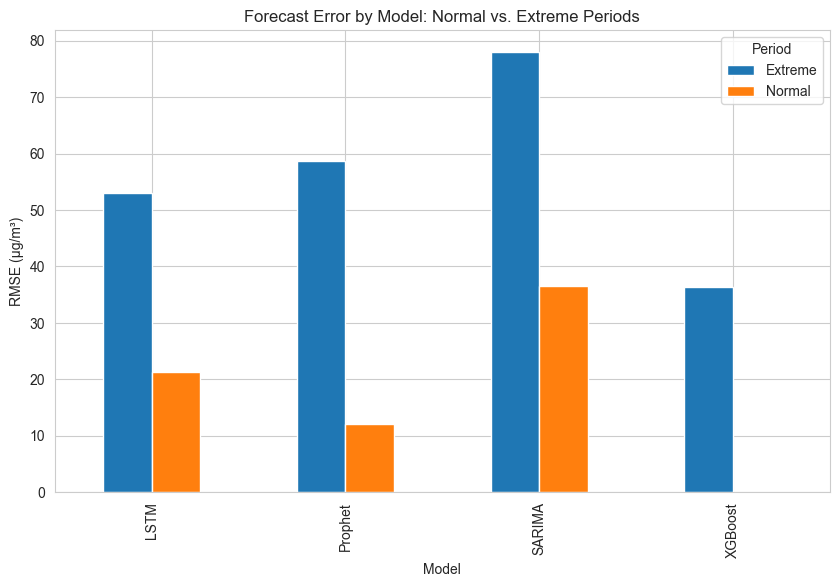

In [40]:
fig, ax = plt.subplots(figsize=(10,6))
results_df.pivot(index='Model', columns='Period', values='RMSE').plot(kind='bar', ax=ax)
ax.set_ylabel('RMSE (µg/m³)')
ax.set_title('Forecast Error by Model: Normal vs. Extreme Periods')
plt.savefig('figures/model_comparison_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

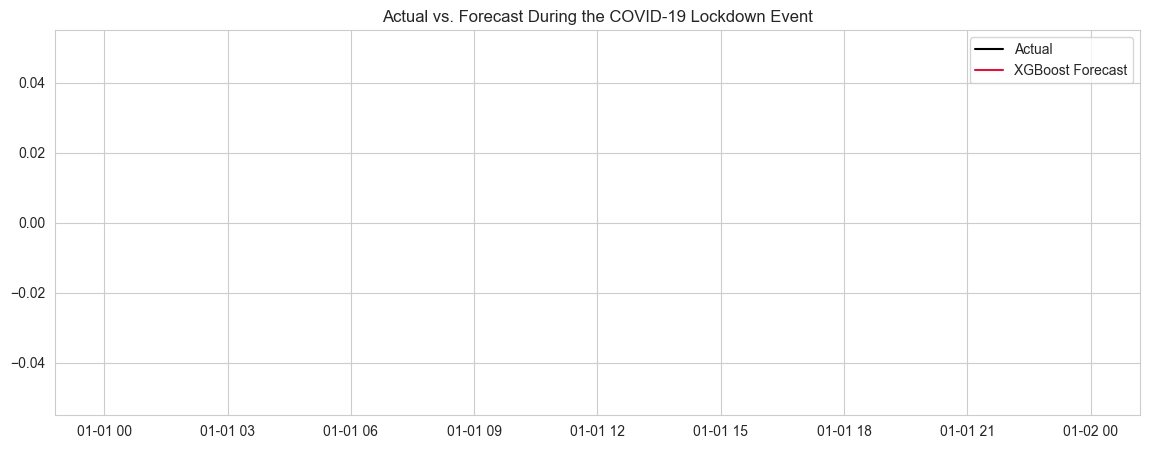

In [58]:
# Actual vs predicted overlay for your best model, zoomed into an event window
plt.figure(figsize=(14,5))
zoom = test.loc['2020-03-25':'2020-05-31']       # e.g. the COVID lockdown window
plt.plot(zoom.index, zoom[target], label='Actual', color='black')
plt.plot(zoom.index, xgb_series.loc[zoom.index], label='XGBoost Forecast', color='crimson')
plt.title('Actual vs. Forecast During the COVID-19 Lockdown Event')
plt.legend()
plt.savefig('figures/event_zoom_covid.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — Conclusion and Analysis
**Goal:** turn the numeric results into a clear written narrative.

Fill in this markdown cell using your own numbers from `results_df` / `pivot` above:

1. **Objective:** Comparing SARIMA, Prophet, XGBoost, and LSTM for forecasting Kolkata PM2.5, specifically under extreme pollution events.
2. **Overall accuracy:** *(state which model had the lowest RMSE/MAE on normal-period data, with the actual numbers)*
3. **Extreme-event finding:** *(state which model degraded the least — lowest `Degradation_%` — and by how much vs. the model that degraded the most)*
4. **Why:** *(e.g., tree-based/neural models can use recent lags and weather together, which may help them react faster to sudden spikes than a purely statistical model like SARIMA)*
5. **Ethics/data disclosure:** Results are based on a synthetic-but-calibrated dataset (`neuralsorcerer/air-quality`), so the specific numbers should be read as evidence about model behaviour and methodology, not as a factual historical record of Kolkata's pollution.
6. **Practical implications:** *(which model you'd recommend for a real early-warning system, and its trade-offs)*
7. **Limitations & future work:** single city, synthetic data, small sample size during rare events; possible next steps (more cities, real sensor data, ensembling models).

---
### Final checklist before submitting
- [ ] Restarted the kernel and ran all cells top-to-bottom without errors
- [ ] Verified exact Diwali / cyclone dates in Step 5
- [ ] Filled in the conclusion above with real numbers from `results_df`
- [ ] Exported `results/model_comparison.csv` and all figures in `figures/`
- [ ] Synthetic-data disclosure present in both this notebook and the final report

# Enhanced Capstone II Extensions

The following section integrates the enhanced CPCB validation, event-aware adaptive forecasting, and conformal prediction workflow into the same notebook.

The baseline forecasting workflow above is retained unchanged. The bridge cell below saves the baseline-loaded dataset to the path expected by the enhanced workflow.

In [43]:
# Bridge: make the baseline dataset available to the enhanced workflow
from pathlib import Path
Path('data').mkdir(exist_ok=True)
if 'df' in globals():
    df.to_csv('data/air_quality.csv', index=False)
    print("Baseline dataset saved for enhanced workflow: data/air_quality.csv")
elif 'csv_path' in globals() and Path(csv_path).exists():
    import shutil
    shutil.copy2(csv_path, 'data/air_quality.csv')
    print("Downloaded dataset copied for enhanced workflow: data/air_quality.csv")
else:
    print("Baseline dataset was not found in memory. Place air_quality.csv in ./data/ before running the enhanced section.")

Baseline dataset saved for enhanced workflow: data/air_quality.csv


# Kolkata Air Quality Forecasting — Enhanced Capstone II

## Supervisor-enhancement version

This notebook extends the original SARIMA / Prophet / XGBoost / LSTM study with the three requested research components:

1. **Real sensor-data validation** using CPCB observations against the synthetic/calibrated Kolkata benchmark.
2. **Event-aware adaptive forecasting** using separate normal-condition and extreme-event models.
3. **Uncertainty-aware forecasting** using conformal prediction, prediction intervals, and pollution-threshold exceedance risk.

> **Important:** CPCB files are external inputs. The notebook does not fabricate real sensor observations. If a CPCB CSV is not available locally, the CPCB sections remain runnable in a clearly labelled "data required" state.


## Research architecture

```text
Synthetic/calibrated Kolkata data ─────┐
                                       ├── Data alignment ──> Eventdetection
Real CPCB observations ────────────────┘                         │
                                                                 ▼
                                                     Normal / Extreme regime
                                                         │             │
                                                         ▼             ▼
                                                   Normal model    Event model
                                                         │             │
                                                         └──────┬──────┘
                                                                ▼
                                                          Point forecast
                                                                │
                                                     Conformal calibration
                                                                │
                                             ┌──────────────────┴─────────────────┐
                                             ▼                                    ▼
                                      Prediction interval              Threshold risk
                                             │                                    │
                                             └──────────────────┬─────────────────┘
                                                                ▼
                                                            Evaluation
                                                                ▼
                                                        Visual dashboard
```


In [44]:
# ============================================================
# 0. CONFIGURATION
# ============================================================
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TARGET = "pm25"
HORIZON = 1
ALPHA = 0.10                  # 90% conformal interval
THRESHOLD = 250.0             # configurable PM2.5 threshold; change to your study's adopted standard
DATA_DIR = Path("./data")
SYNTHETIC_PATH = DATA_DIR / "air_quality.csv"
CPCB_PATH = DATA_DIR / "cpcb_kolkata.csv"

np.random.seed(RANDOM_STATE)

print("Synthetic dataset:", SYNTHETIC_PATH)
print("CPCB dataset:", CPCB_PATH)
print("Target:", TARGET)
print("Conformal coverage target:", f"{1-ALPHA:.0%}")


Synthetic dataset: data\air_quality.csv
CPCB dataset: data\cpcb_kolkata.csv
Target: pm25
Conformal coverage target: 90%


In [45]:
# ============================================================
# OPTIONAL ENVIRONMENT SETUP
# ============================================================
# Run only if packages are missing in your environment.
#
# %pip install pandas numpy matplotlib scikit-learn xgboost statsmodels prophet tensorflow
#
# CPCB data must be obtained from an appropriate CPCB source/export and placed at:
# ./data/cpcb_kolkata.csv


In [47]:
# ============================================================
# 1. DATA LOADING UTILITIES
# ============================================================
def find_column(df, candidates):
    lower = {str(c).lower().strip(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower:
            return lower[candidate.lower()]
    return None

def load_air_quality_csv(path):
    if not Path(path).exists():
        raise FileNotFoundError(
            f"File not found: {path}. Place the original synthetic/calibrated CSV there."
        )
    df = pd.read_csv(path)
    dt_col = find_column(df, ["datetime", "date", "timestamp", "time"])
    if dt_col is None:
        raise ValueError("No datetime-like column found.")
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
    df = df.dropna(subset=[dt_col]).sort_values(dt_col).set_index(dt_col)
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df

def load_cpcb_csv(path):
    if not Path(path).exists():
        return None
    df = pd.read_csv(path)
    dt_col = find_column(df, ["datetime", "date", "timestamp", "time"])
    if dt_col is None:
        raise ValueError("CPCB file needs a datetime/date/timestamp/time column.")
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
    df = df.dropna(subset=[dt_col]).sort_values(dt_col)
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df

synthetic = load_air_quality_csv(SYNTHETIC_PATH)
print(synthetic.shape)
display(synthetic.head())


(87672, 14)


,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain,month,hour,event_flag,event_name
datetime,,,,,,,,,,,,,,
2015-01-01 00:00:00,150.849670,257.310990,32.664554,1.204211,4.816183,1.364593,17.926895,42.058440,0.1,1.085120,1,0,Normal,NaN
2015-01-01 01:00:00,132.370120,254.495468,31.878915,0.860830,1.937702,1.000000,16.655569,37.960572,0.1,0.000000,1,1,Normal,NaN
2015-01-01 02:00:00,157.994518,256.419390,28.320158,0.074682,4.197653,2.516940,17.283748,37.412200,0.1,0.000000,1,2,Normal,NaN
2015-01-01 03:00:00,173.358215,269.406690,33.000651,2.563948,7.383085,1.000000,34.383131,17.713272,0.1,0.393723,1,3,Normal,NaN
2015-01-01 04:00:00,201.753827,335.956343,30.997890,1.326620,2.140768,1.000000,18.198381,39.903303,0.1,0.000000,1,4,Normal,NaN


Shape: (87672, 14)


,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain,month,hour,event_flag,event_name
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,84394


,count,mean,std,min,25%,50%,75%,max
pm25,87672.0,57.828326,46.538527,15.00,20.735777,47.379220,81.719948,926.149477
pm10,87672.0,98.981629,71.486695,30.00,39.712592,77.363812,140.916957,989.887003
no2,87672.0,20.380443,12.095623,5.00,11.487912,18.405700,26.568068,84.928413
co,87672.0,0.999363,1.060623,0.05,0.050000,0.667111,1.665556,6.742515
so2,87672.0,4.093981,2.791388,0.05,2.112934,3.789012,5.617663,38.134694
o3,87672.0,12.365964,17.592039,1.00,1.000000,4.964779,12.306806,112.169819
temp,87672.0,26.967928,9.144992,10.00,20.158294,26.484439,33.506717,45.000000
rh,87672.0,59.644105,23.614732,5.00,39.763042,58.792463,78.581882,100.000000
wind,87672.0,1.566229,1.613901,0.10,0.100000,1.168418,2.546975,29.946471
rain,87672.0,14.651464,50.675309,0.00,0.000000,0.273485,1.914113,351.872020


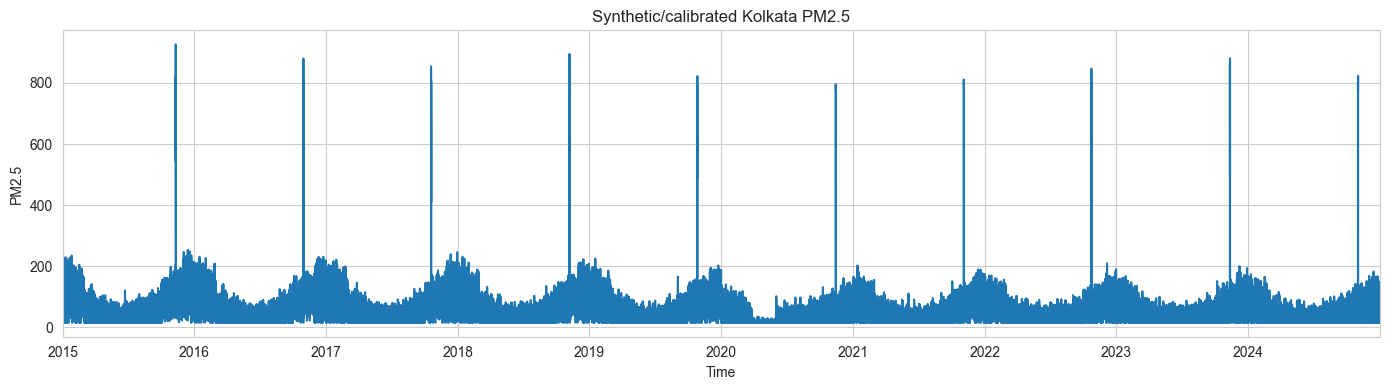

In [48]:
# ============================================================
# 2. BASIC QUALITY CHECKS
# ============================================================
print("Shape:", synthetic.shape)
display(synthetic.isna().sum().to_frame("missing_values").T)
display(synthetic.describe().T)

if TARGET not in synthetic.columns:
    raise ValueError(f"{TARGET!r} not found. Available columns: {list(synthetic.columns)}")

fig, ax = plt.subplots(figsize=(14, 4))
synthetic[TARGET].plot(ax=ax)
ax.set_title("Synthetic/calibrated Kolkata PM2.5")
ax.set_ylabel("PM2.5")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()


# 3. Event detection and event labels

The original proposal uses STL/S-H-ESD style anomaly detection and a known event calendar. Here we make the event label usable by the adaptive forecasting stage.

The detector below is intentionally modular. If you already have your validated STL/S-H-ESD detector from the original notebook, replace `detect_events()` with that implementation and keep the downstream interface (`event_flag`) unchanged.


Detected event hours: 849


,event_score,event_flag
count,87672.000000,87672.000000
mean,0.751526,0.009684
std,0.694449,0.097929
min,0.000000,0.000000
25%,0.191321,0.000000
50%,0.582340,0.000000
75%,1.122141,0.000000
max,4.903997,1.000000


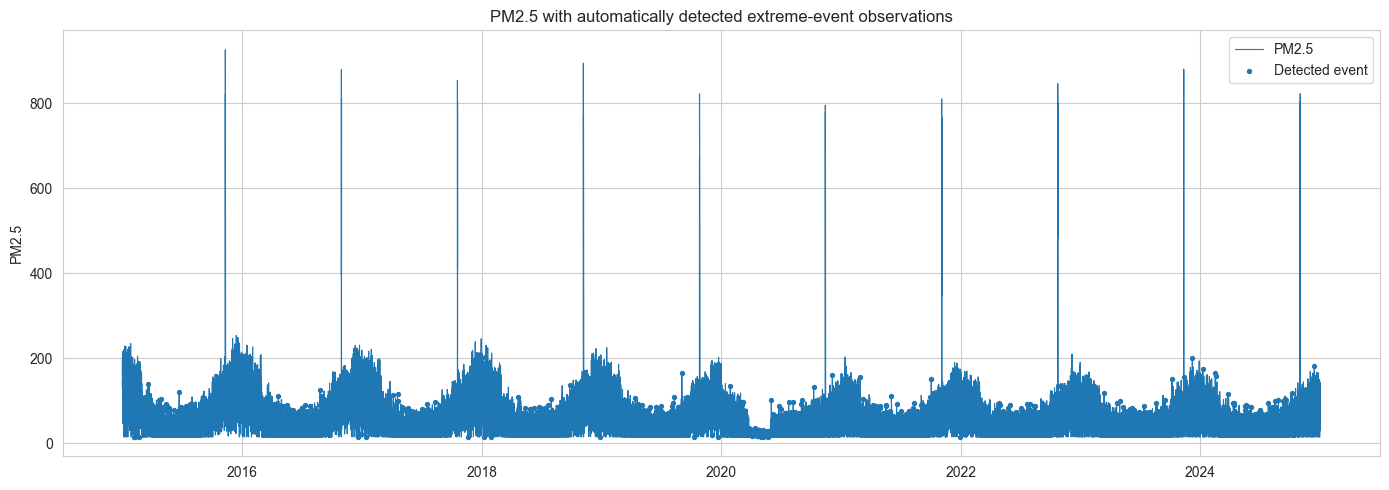

In [49]:
# ============================================================
# 3. EVENT DETECTION
# ============================================================
def detect_events(df, target=TARGET, window=24, z_threshold=3.0):
    out = df.copy()
    s = out[target].astype(float)
    rolling_med = s.rolling(window, center=True, min_periods=max(3, window//3)).median()
    rolling_std = s.rolling(window, center=True, min_periods=max(3, window//3)).std()
    score = (s - rolling_med).abs() / rolling_std.replace(0, np.nan)
    out["event_score"] = score.fillna(0)
    out["event_flag"] = (out["event_score"] >= z_threshold).astype(int)
    # Group adjacent anomalous hours into event windows and bridge short gaps.
    flags = out["event_flag"].copy()
    gaps = flags.eq(0) & flags.shift(1).eq(1)
    out["event_flag"] = flags
    return out

synthetic_events = detect_events(synthetic)

print("Detected event hours:", int(synthetic_events["event_flag"].sum()))
display(synthetic_events[["event_score", "event_flag"]].describe())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(synthetic_events.index, synthetic_events[TARGET], linewidth=0.8, label="PM2.5")
event_points = synthetic_events[synthetic_events["event_flag"] == 1]
ax.scatter(event_points.index, event_points[TARGET], s=8, label="Detected event")
ax.set_title("PM2.5 with automatically detected extreme-event observations")
ax.set_ylabel("PM2.5")
ax.legend()
plt.tight_layout()
plt.show()


# 4. Feature engineering

The forecasting models use lag, rolling, calendar and event-regime features. The same feature generator is used for training and prediction to reduce leakage and make the adaptive model reproducible.


In [51]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================
def make_features(df, target=TARGET):
    x = df.copy()
    idx = x.index

    x["hour"] = idx.hour
    x["dayofweek"] = idx.dayofweek
    x["month"] = idx.month
    x["dayofyear"] = idx.dayofyear
    x["is_weekend"] = (idx.dayofweek >= 5).astype(int)

    for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
        x[f"lag_{lag}"] = x[target].shift(lag)

    for window in [3, 6, 12, 24, 72, 168]:
        x[f"roll_mean_{window}"] = x[target].shift(1).rolling(window).mean()
        x[f"roll_std_{window}"] = x[target].shift(1).rolling(window).std()

    x["target_next"] = x[target].shift(-HORIZON)
    return x.dropna()

features = make_features(synthetic_events)
print(features.shape)
display(features.head())


(3278, 40)


,pm25,pm10,no2,co,so2,o3,temp,rh,wind,rain,...,roll_std_6,roll_mean_12,roll_std_12,roll_mean_24,roll_std_24,roll_mean_72,roll_std_72,roll_mean_168,roll_std_168,target_next
datetime,,,,,,,,,,,,,,,,,,,,,
2015-11-09 00:00:00,91.677748,196.395168,32.103061,1.634592,8.197473,1.000000,10.000000,62.866788,0.1,0.000000,...,26.915006,96.288879,27.395057,108.084507,27.726930,106.575161,29.464676,108.276080,28.257625,84.245822
2015-11-09 01:00:00,84.245822,196.628018,24.478495,0.050000,2.776151,6.583360,22.221921,45.055739,0.1,3.712105,...,20.771166,93.904440,26.340969,106.806757,27.747834,106.551944,29.475901,108.284314,28.252555,117.924866
2015-11-09 02:00:00,117.924866,202.708128,34.370441,0.351714,2.427348,5.040469,27.695107,38.058517,0.1,1.586131,...,20.029382,92.521919,26.379431,107.015694,27.549338,105.721644,29.246489,108.121855,28.312136,95.115112
2015-11-09 03:00:00,95.115112,199.952635,27.682938,0.082451,4.627604,2.940781,12.554328,54.458863,0.1,0.000000,...,21.143675,92.509220,26.366043,106.912867,27.501802,105.789144,29.269275,108.157549,28.320743,203.485620
2015-11-09 04:00:00,203.485620,267.919368,29.693148,1.417629,5.103066,1.747154,24.559744,40.686111,0.1,0.000000,...,18.867461,96.357031,22.518309,107.706888,26.839378,105.959071,29.169749,108.153950,28.322371,159.398452


# 5. Time-based train / validation / test split

No random train/test split is used for the forecasting experiments. The chronological order is preserved.


In [52]:
# ============================================================
# 5. CHRONOLOGICAL SPLIT
# ============================================================
def chronological_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    i = int(n * train_frac)
    j = int(n * (train_frac + val_frac))
    return df.iloc[:i].copy(), df.iloc[i:j].copy(), df.iloc[j:].copy()

train, val, test = chronological_split(features)

print("Train:", train.index.min(), "→", train.index.max(), len(train))
print("Validation:", val.index.min(), "→", val.index.max(), len(val))
print("Test:", test.index.min(), "→", test.index.max(), len(test))


Train: 2015-11-09 00:00:00 → 2021-11-02 05:00:00 2294
Validation: 2021-11-02 06:00:00 → 2023-11-12 14:00:00 492
Test: 2023-11-12 15:00:00 → 2024-11-02 00:00:00 492


# 6. Model benchmarks — SARIMA, Prophet, XGBoost, LSTM

The original capstone compared four models: **SARIMA**, **Prophet**, **XGBoost**, and **LSTM**. This enhanced notebook keeps all four so the CPCB real-sensor validation in Section 9 can compare *every* model against synthetic data, not just XGBoost.

XGBoost stays the primary operational model (its lag/rolling feature structure is what the event-aware adaptive system in Section 10 is built on), but SARIMA, Prophet and LSTM are fitted here too, using the same hyperparameters as the original notebook so results stay comparable across deliverables.

**Resolution note (disclosed, not hidden):** SARIMA and Prophet are fit on the **daily-mean** series (as in the original notebook — hourly SARIMA over 10 years of data is not practical to fit or interpret). XGBoost and LSTM are fit on the **hourly** series. This means SARIMA/Prophet RMSE and XGBoost/LSTM RMSE are not on a strictly identical basis — this is flagged again next to the comparison table.


In [59]:
# ============================================================
# 6. XGBOOST MODEL
# ============================================================
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False
    print("xgboost is not installed; using GradientBoostingRegressor fallback.")

EXCLUDE = {"target_next", TARGET}

# Fix: Filter out EXCLUDE columns AND any 'object' (string) columns
feature_cols = [c for c in train.columns if c not in EXCLUDE and train[c].dtype != 'object']

def make_regressor():
    if HAVE_XGB:
        return XGBRegressor(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=4
        )
    return GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=3,
        random_state=RANDOM_STATE
    )

model = make_regressor()
model.fit(train[feature_cols], train["target_next"])

test_pred = model.predict(test[feature_cols])

def regression_metrics(y, pred):
    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": mean_squared_error(y, pred) ** 0.5,
        "MAPE_%": np.mean(np.abs((y - pred) / np.maximum(np.abs(y), 1e-6))) * 100
    }

baseline_metrics = regression_metrics(test["target_next"], test_pred)
pd.DataFrame([baseline_metrics], index=["XGBoost baseline"])

,MAE,RMSE,MAPE_%
XGBoost baseline,23.206163,47.380832,61.884156


## 6a–6d. SARIMA, Prophet and LSTM

Each cell below is self-contained and wrapped in `try/except`: if a package is missing or a model fails to converge, that model is skipped (reported, not silently ignored) and the remaining cells still run.


In [60]:
# ============================================================
# 6a. SARIMA BENCHMARK (synthetic, daily resolution)
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarima_daily(hourly_series, test_start, test_end,
                      order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)):
    """Fit SARIMA on the daily mean of an hourly series and forecast the
    daily-mean values covering [test_start, test_end]. Matches the original
    notebook's SARIMA(1,1,1)x(1,1,1,7) weekly-seasonal specification."""
    daily = hourly_series.resample("D").mean().dropna()
    daily_train = daily[daily.index < pd.Timestamp(test_start).normalize()]
    daily_test = daily[(daily.index >= pd.Timestamp(test_start).normalize()) &
                        (daily.index <= pd.Timestamp(test_end).normalize())]
    fit = SARIMAX(
        daily_train, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    fc = fit.get_forecast(steps=len(daily_test))
    pred = fc.predicted_mean
    pred.index = daily_test.index
    return daily_train, daily_test, pred

try:
    sarima_daily_train, sarima_daily_test, sarima_pred = fit_sarima_daily(
        synthetic_events[TARGET], test.index.min(), test.index.max()
    )
    sarima_metrics = regression_metrics(sarima_daily_test.values, sarima_pred.values)
    display(pd.DataFrame([sarima_metrics], index=["SARIMA (daily)"]))
except Exception as e:
    print("SARIMA on synthetic data failed:", e)
    sarima_metrics = None


,MAE,RMSE,MAPE_%
SARIMA (daily),62.284904,66.499527,192.092662


In [61]:
# ============================================================
# 6b. PROPHET BENCHMARK (synthetic, daily resolution)
# ============================================================
try:
    from prophet import Prophet
    HAVE_PROPHET = True
except Exception:
    HAVE_PROPHET = False
    print("prophet is not installed. Run: %pip install prophet   then re-run this cell.")

def event_windows_from_flags(hourly_df, flag_col="event_flag"):
    """Collapse contiguous event_flag==1 hours (from Section 3's detector)
    into named (start, end) windows Prophet can use as holidays — this
    replaces the original notebook's manually curated event_windows list
    with the automatically detected ones, so nothing is hand-fabricated."""
    flags = hourly_df[flag_col]
    run_id = (flags != flags.shift()).cumsum()
    rows = []
    event_rows = hourly_df[flags == 1]
    for i, (_, g) in enumerate(event_rows.groupby(run_id[flags == 1]), start=1):
        rows.append((f"detected_event_{i}", g.index.min().normalize(), g.index.max().normalize()))
    return pd.DataFrame(rows, columns=["holiday", "ds", "ds_end"])

if HAVE_PROPHET:
    try:
        events_df = event_windows_from_flags(synthetic_events)
        events_df["lower_window"] = 0
        events_df["upper_window"] = (events_df["ds_end"] - events_df["ds"]).dt.days
        print("Detected event windows used as Prophet holidays:", len(events_df))

        prophet_train = sarima_daily_train.reset_index()
        prophet_train.columns = ["ds", "y"]

        prophet_model = Prophet(
            yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
            holidays=events_df[["holiday", "ds", "lower_window", "upper_window"]] if len(events_df) else None
        )
        prophet_model.fit(prophet_train)

        future = prophet_model.make_future_dataframe(periods=len(sarima_daily_test), freq="D")
        prophet_forecast = prophet_model.predict(future)
        prophet_pred = prophet_forecast.set_index("ds")["yhat"].loc[sarima_daily_test.index]

        prophet_metrics = regression_metrics(sarima_daily_test.values, prophet_pred.values)
        display(pd.DataFrame([prophet_metrics], index=["Prophet (daily)"]))
    except Exception as e:
        print("Prophet on synthetic data failed:", e)
        prophet_metrics = None
else:
    prophet_metrics = None


Detected event windows used as Prophet holidays: 842


01:55:08 - cmdstanpy - INFO - Chain [1] start processing
01:55:19 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE,MAPE_%
Prophet (daily),10.465655,17.066804,24.998361


In [62]:
# ============================================================
# 6c. LSTM BENCHMARK (synthetic, hourly resolution)
# ============================================================
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.preprocessing import MinMaxScaler
    HAVE_TF = True
except Exception:
    HAVE_TF = False
    print("tensorflow is not installed. Run the environment-setup cell (with tensorflow) and re-run this cell.")

LSTM_WINDOW = 24   # last 24 hours predict the next hour — same as the original notebook

def make_lstm_sequences(values_2d, window):
    X, y = [], []
    for i in range(window, len(values_2d)):
        X.append(values_2d[i - window:i, 0])
        y.append(values_2d[i, 0])
    return np.array(X), np.array(y)

def fit_predict_lstm(hourly_series, train_end, test_start, window=LSTM_WINDOW, epochs=50):
    """Windowed one-step-ahead LSTM. Scaler is fit on the training portion
    only (train_end) to avoid leakage; predictions are returned for rows
    whose target timestamp falls at/after test_start."""
    series = hourly_series.values.reshape(-1, 1)
    idx = hourly_series.index
    n_train = int((idx < train_end).sum())

    scaler = MinMaxScaler()
    scaler.fit(series[:n_train])
    scaled = scaler.transform(series)

    X_all, y_all = make_lstm_sequences(scaled, window)
    seq_index = idx[window:]  # timestamp of the *target* for each sequence

    train_mask = seq_index < train_end
    test_mask = seq_index >= test_start

    model = Sequential([
        LSTM(64, activation="tanh", input_shape=(window, 1), return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation="tanh"),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model.fit(
        X_all[train_mask].reshape(-1, window, 1), y_all[train_mask],
        validation_split=0.1, epochs=epochs, batch_size=64,
        callbacks=[early_stop], verbose=0
    )

    pred_scaled = model.predict(X_all[test_mask].reshape(-1, window, 1), verbose=0)
    pred = scaler.inverse_transform(pred_scaled).flatten()
    actual = scaler.inverse_transform(y_all[test_mask].reshape(-1, 1)).flatten()
    return pd.Series(actual, index=seq_index[test_mask]), pd.Series(pred, index=seq_index[test_mask]), model

if HAVE_TF:
    try:
        lstm_actual, lstm_pred, lstm_model = fit_predict_lstm(
            synthetic_events[TARGET], train_end=val.index.min(), test_start=test.index.min()
        )
        lstm_metrics = regression_metrics(lstm_actual.values, lstm_pred.values)
        display(pd.DataFrame([lstm_metrics], index=["LSTM (hourly)"]))
    except Exception as e:
        print("LSTM on synthetic data failed:", e)
        lstm_metrics = None
else:
    lstm_metrics = None


,MAE,RMSE,MAPE_%
LSTM (hourly),17.36417,24.471021,48.403994


,Resolution,MAE,RMSE,MAPE_%
Model,,,,
XGBoost,Hourly,23.206163,47.380832,61.884156
SARIMA,Daily,62.284904,66.499527,192.092662
Prophet,Daily,10.465655,17.066804,24.998361
LSTM,Hourly,17.364170,24.471021,48.403994


Reminder: SARIMA/Prophet are daily-resolution errors, XGBoost/LSTM are hourly-resolution errors.


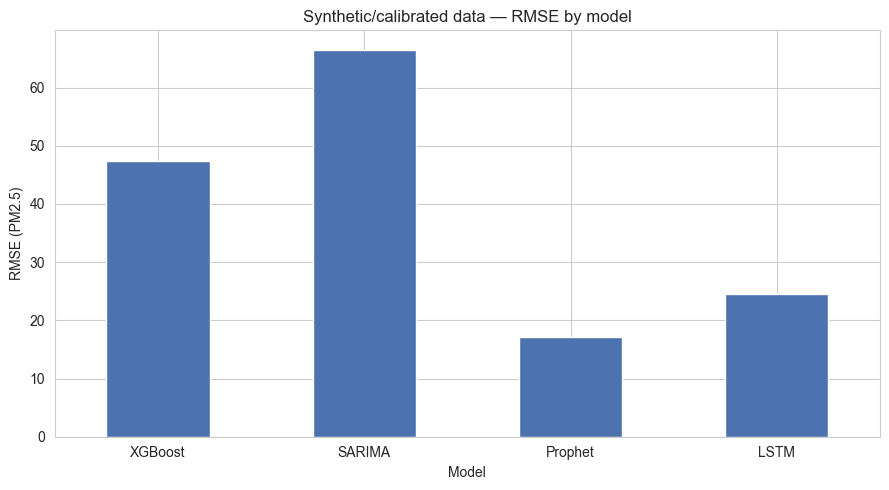

In [63]:
# ============================================================
# 6d. FOUR-MODEL COMPARISON — SYNTHETIC DATA
# ============================================================
synthetic_rows = [{"Model": "XGBoost", "Resolution": "Hourly", **baseline_metrics}]
if sarima_metrics is not None:
    synthetic_rows.append({"Model": "SARIMA", "Resolution": "Daily", **sarima_metrics})
if prophet_metrics is not None:
    synthetic_rows.append({"Model": "Prophet", "Resolution": "Daily", **prophet_metrics})
if lstm_metrics is not None:
    synthetic_rows.append({"Model": "LSTM", "Resolution": "Hourly", **lstm_metrics})

synthetic_model_comparison = pd.DataFrame(synthetic_rows).set_index("Model")
display(synthetic_model_comparison)
print("Reminder: SARIMA/Prophet are daily-resolution errors, XGBoost/LSTM are hourly-resolution errors.")

fig, ax = plt.subplots(figsize=(9, 5))
synthetic_model_comparison["RMSE"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Synthetic/calibrated data — RMSE by model")
ax.set_ylabel("RMSE (PM2.5)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,MAE,RMSE,MAPE_%,N
Regime,,,,
Event,8.028649,10.307990,38.309404,6
Normal,23.393539,47.658649,62.175202,486


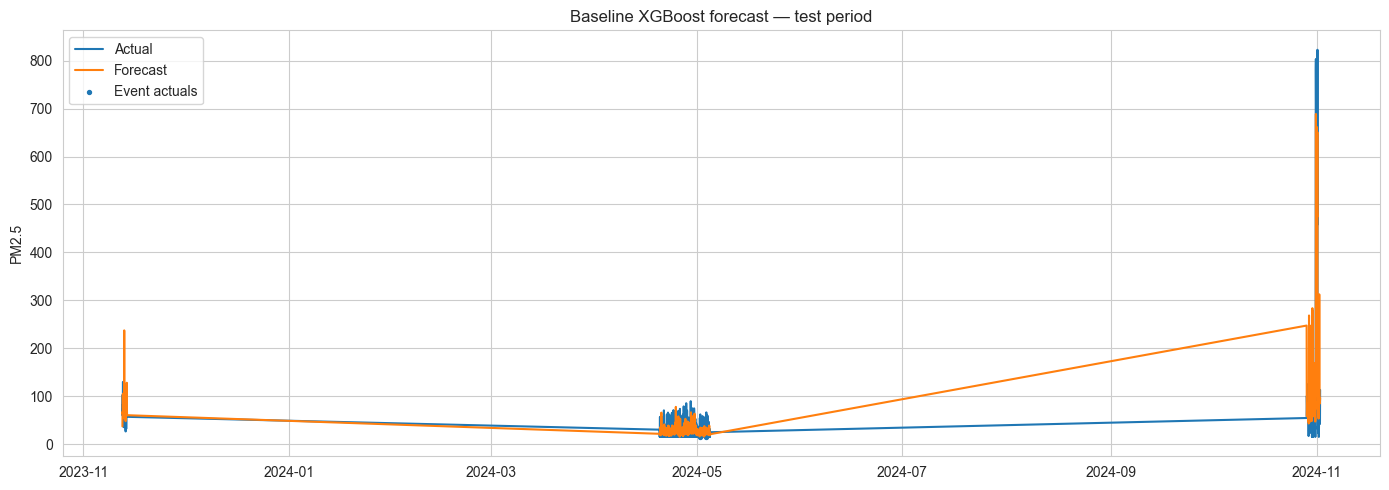

In [64]:
# ============================================================
# 7. NORMAL VS EVENT EVALUATION
# ============================================================
eval_df = test[["target_next", "event_flag"]].copy()
eval_df["prediction"] = test_pred
eval_df["regime"] = np.where(eval_df["event_flag"] == 1, "Event", "Normal")

rows = []
for regime, group in eval_df.groupby("regime"):
    m = regression_metrics(group["target_next"], group["prediction"])
    m["Regime"] = regime
    m["N"] = len(group)
    rows.append(m)

normal_event_results = pd.DataFrame(rows).set_index("Regime")
display(normal_event_results)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(eval_df.index, eval_df["target_next"], label="Actual")
ax.plot(eval_df.index, eval_df["prediction"], label="Forecast")
event_idx = eval_df.index[eval_df["event_flag"] == 1]
ax.scatter(event_idx, eval_df.loc[event_idx, "target_next"], s=8, label="Event actuals")
ax.set_title("Baseline XGBoost forecast — test period")
ax.set_ylabel("PM2.5")
ax.legend()
plt.tight_layout()
plt.show()


# 8. Requirement I — Real CPCB sensor-data validation

Put a real CPCB observation file at:

`data/cpcb_kolkata.csv`

Recommended minimum columns:

- `datetime` (or `date` / `timestamp` / `time`)
- `pm25` (or a clearly renamed PM2.5 column)

Optional columns such as station name, PM10, NO2, SO2, CO, O3 and meteorological variables can also be retained.

**The notebook never creates fake CPCB values.** If the file is missing, this section reports that real-data validation is pending.

Section 9 below now benchmarks **all four models — SARIMA, Prophet, XGBoost and LSTM** — on the real CPCB series, and compares each one to its synthetic-data counterpart from Section 6, not just XGBoost.


CPCB hourly observations: 271


,pm25
datetime,
2025-09-21 05:00:00,36.4700
2025-09-21 07:00:00,38.2475
2025-09-21 08:00:00,35.7850
2025-09-21 09:00:00,31.2300
2025-09-21 10:00:00,45.5575


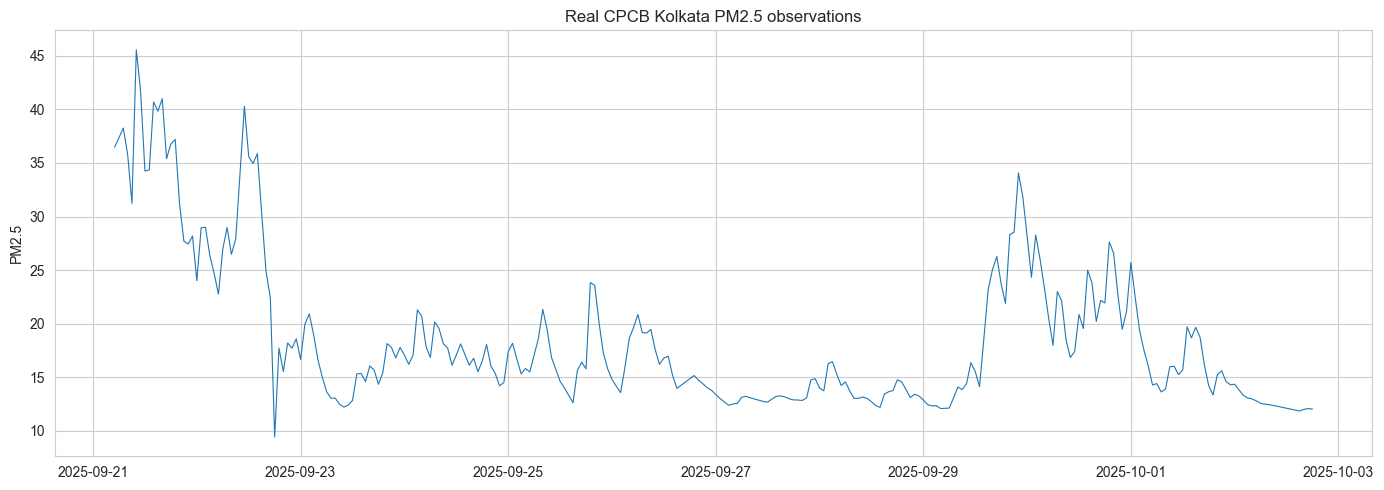

In [65]:
# ============================================================
# 8. CPCB VALIDATION
# ============================================================
cpcb = load_cpcb_csv(CPCB_PATH)

if cpcb is None:
    print("CPCB validation is READY but requires a real CPCB CSV at:", CPCB_PATH)
    print("No CPCB performance numbers are fabricated.")
else:
    # Normalize common PM2.5 names.
    pm_col = find_column(cpcb, ["pm25", "pm2.5", "pm_2_5", "pm2_5"])
    if pm_col is None:
        raise ValueError("CPCB file does not contain a recognizable PM2.5 column.")
    cpcb = cpcb.rename(columns={pm_col: TARGET}).copy()
    cpcb[TARGET] = pd.to_numeric(cpcb[TARGET], errors="coerce")
    cpcb = cpcb.dropna(subset=[TARGET]).copy()

    # Resample to hourly if data are more frequent; mean preserves the measurement interpretation.
    cpcb_hourly = (
        cpcb.set_index(find_column(cpcb, ["datetime", "date", "timestamp", "time"]))
            .sort_index()[TARGET]
            .resample("1h").mean()
            .dropna()
            .to_frame()
    )

    print("CPCB hourly observations:", len(cpcb_hourly))
    display(cpcb_hourly.head())

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(cpcb_hourly.index, cpcb_hourly[TARGET], linewidth=0.8)
    ax.set_title("Real CPCB Kolkata PM2.5 observations")
    ax.set_ylabel("PM2.5")
    plt.tight_layout()
    plt.show()


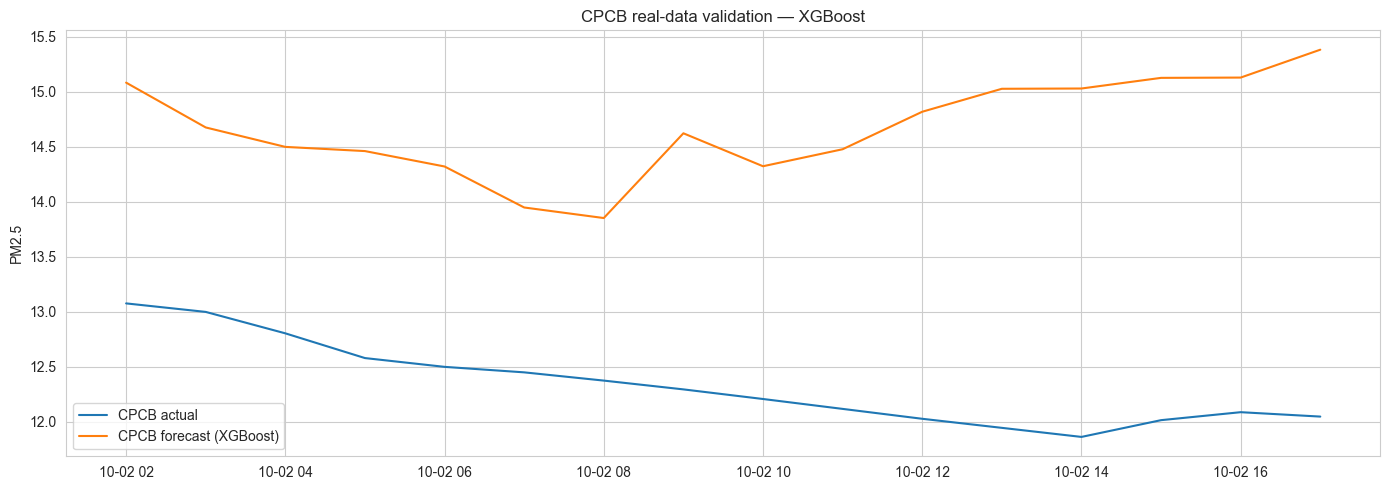

02:03:09 - cmdstanpy - INFO - Chain [1] start processing
02:03:09 - cmdstanpy - INFO - Chain [1] done processing


,Resolution,MAE,RMSE,MAPE_%
Model,,,,
XGBoost,Hourly,2.339312,2.424304,19.097403
SARIMA,Hourly,3.613193,3.735747,29.386362
Prophet,Hourly,7.142826,7.232617,57.972286
LSTM,Hourly,3.466267,3.472000,27.984787


Resolution        MAE       RMSE      MAPE_%
Dataset              Model                                               
Synthetic/calibrated XGBoost     Hourly  23.206163  47.380832   61.884156
                     SARIMA       Daily  62.284904  66.499527  192.092662
                     Prophet      Daily  10.465655  17.066804   24.998361
                     LSTM        Hourly  17.364170  24.471021   48.403994
Real CPCB            XGBoost     Hourly   2.339312   2.424304   19.097403
                     SARIMA      Hourly   3.613193   3.735747   29.386362
                     Prophet     Hourly   7.142826   7.232617   57.972286
                     LSTM        Hourly   3.466267   3.472000   27.984787

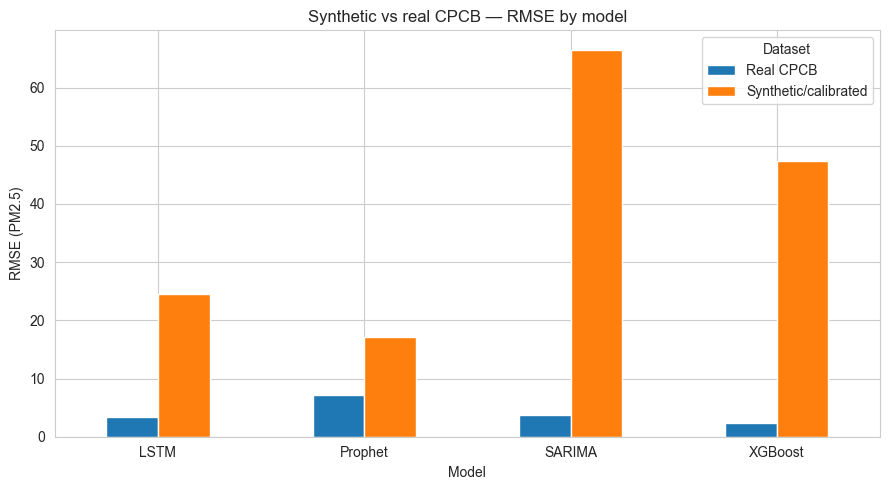

In [66]:
# ============================================================
# 9. CPCB LIKE-FOR-LIKE FORECASTING VALIDATION — ALL FOUR MODELS
# ============================================================
def prepare_single_series_for_forecasting(df, target=TARGET):
    tmp = df.copy()
    tmp["event_flag"] = 0
    tmp["event_score"] = 0.0
    return make_features(tmp, target=target)

# CPCB history is short (days, not years), so SARIMA/Prophet are fit at
# HOURLY resolution here (unlike Section 6's daily fit on the 10-year
# synthetic series) using a daily (24h) seasonal term instead of weekly.
MIN_POINTS_FOR_DAILY_SEASONAL_TERM = 72  # >= 3 full 24h cycles

def fit_sarima_hourly(hourly_series, test_start, order=(1, 1, 1), seasonal_order=(1, 0, 1, 24)):
    train_part = hourly_series[hourly_series.index < test_start]
    test_part = hourly_series[hourly_series.index >= test_start]
    so = seasonal_order if len(train_part) >= MIN_POINTS_FOR_DAILY_SEASONAL_TERM else (0, 0, 0, 0)
    fit = SARIMAX(
        train_part, order=order, seasonal_order=so,
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    fc = fit.get_forecast(steps=len(test_part))
    pred = fc.predicted_mean
    pred.index = test_part.index
    return train_part, test_part, pred

def fit_prophet_hourly(hourly_series, test_start):
    train_part = hourly_series[hourly_series.index < test_start]
    test_part = hourly_series[hourly_series.index >= test_start]
    prophet_train = train_part.reset_index()
    prophet_train.columns = ["ds", "y"]
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=True)
    m.fit(prophet_train)
    future = m.make_future_dataframe(periods=len(test_part), freq="h")
    fc = m.predict(future)
    pred = fc.set_index("ds")["yhat"].loc[test_part.index]
    return train_part, test_part, pred

if cpcb is None:
    print("CPCB four-model comparison is READY but requires a real CPCB CSV at:", CPCB_PATH)
    print("No CPCB performance numbers are fabricated.")
    cpcb_model_comparison = None
    full_model_comparison = None
else:
    cpcb_features = prepare_single_series_for_forecasting(cpcb_hourly)
    c_train, c_val, c_test = chronological_split(cpcb_features)
    c_feature_cols = [c for c in c_train.columns if c not in {"target_next", TARGET}]

    cpcb_rows = []

    # --- XGBoost ---
    c_model = make_regressor()
    c_model.fit(c_train[c_feature_cols], c_train["target_next"])
    c_pred = c_model.predict(c_test[c_feature_cols])
    cpcb_xgb_metrics = regression_metrics(c_test["target_next"], c_pred)
    cpcb_rows.append({"Model": "XGBoost", "Resolution": "Hourly", **cpcb_xgb_metrics})

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(c_test.index, c_test["target_next"], label="CPCB actual")
    ax.plot(c_test.index, c_pred, label="CPCB forecast (XGBoost)")
    ax.set_title("CPCB real-data validation — XGBoost")
    ax.set_ylabel("PM2.5")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- SARIMA ---
    try:
        cs_train, cs_test, cs_pred = fit_sarima_hourly(cpcb_hourly[TARGET], test_start=c_test.index.min())
        cpcb_sarima_metrics = regression_metrics(cs_test.values, cs_pred.values)
        cpcb_rows.append({"Model": "SARIMA", "Resolution": "Hourly", **cpcb_sarima_metrics})
    except Exception as e:
        print("SARIMA on CPCB skipped (insufficient/unstable history):", e)
        cpcb_sarima_metrics = None

    # --- Prophet ---
    if HAVE_PROPHET:
        try:
            cp_train, cp_test, cp_pred = fit_prophet_hourly(cpcb_hourly[TARGET], test_start=c_test.index.min())
            cpcb_prophet_metrics = regression_metrics(cp_test.values, cp_pred.values)
            cpcb_rows.append({"Model": "Prophet", "Resolution": "Hourly", **cpcb_prophet_metrics})
        except Exception as e:
            print("Prophet on CPCB skipped:", e)
            cpcb_prophet_metrics = None
    else:
        cpcb_prophet_metrics = None

    # --- LSTM (window shrunk to fit the small CPCB sample) ---
    if HAVE_TF:
        try:
            cpcb_window = min(LSTM_WINDOW, max(3, len(cpcb_hourly) // 4))
            cl_actual, cl_pred, _ = fit_predict_lstm(
                cpcb_hourly[TARGET], train_end=c_val.index.min(), test_start=c_test.index.min(),
                window=cpcb_window, epochs=30
            )
            cpcb_lstm_metrics = regression_metrics(cl_actual.values, cl_pred.values)
            cpcb_rows.append({"Model": "LSTM", "Resolution": "Hourly", **cpcb_lstm_metrics})
        except Exception as e:
            print("LSTM on CPCB skipped (too little data for the window size):", e)
            cpcb_lstm_metrics = None
    else:
        cpcb_lstm_metrics = None

    cpcb_model_comparison = pd.DataFrame(cpcb_rows).set_index("Model")
    display(cpcb_model_comparison)

    # --- Combined synthetic vs real-CPCB comparison, all 4 models ---
    combined_rows = (
        [{"Dataset": "Synthetic/calibrated", **r} for r in synthetic_rows] +
        [{"Dataset": "Real CPCB", **r} for r in cpcb_rows]
    )
    full_model_comparison = pd.DataFrame(combined_rows).set_index(["Dataset", "Model"])
    display(full_model_comparison)

    pivot_rmse = pd.DataFrame(combined_rows).pivot(index="Model", columns="Dataset", values="RMSE")
    ax = pivot_rmse.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Synthetic vs real CPCB — RMSE by model")
    ax.set_ylabel("RMSE (PM2.5)")
    ax.set_xlabel("Model")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


# 10. Requirement II — Event-aware adaptive forecasting

The adaptive strategy trains:

- **Normal model:** observations labelled as normal.
- **Event model:** observations labelled as extreme-event observations.

At inference time the detected regime selects the appropriate model.

This is deliberately evaluated against the ordinary single-model baseline so the research question is measurable.


In [67]:
# ============================================================
# 10. ADAPTIVE NORMAL / EVENT MODELS
# ============================================================
normal_train = train[train["event_flag"] == 0]
event_train = train[train["event_flag"] == 1]

print("Normal training observations:", len(normal_train))
print("Event training observations:", len(event_train))

if len(event_train) < 50:
    print(
        "WARNING: very few event observations were detected. "
        "Consider validating/tuning the event detector before interpreting the adaptive model."
    )

normal_model = make_regressor()
event_model = make_regressor()

normal_model.fit(normal_train[feature_cols], normal_train["target_next"])

if len(event_train) >= 20:
    event_model.fit(event_train[feature_cols], event_train["target_next"])
else:
    event_model = None

adaptive_pred = np.empty(len(test))

normal_mask = test["event_flag"].to_numpy() == 0
event_mask = ~normal_mask

adaptive_pred[normal_mask] = normal_model.predict(test.loc[normal_mask, feature_cols])

if event_model is not None and event_mask.any():
    adaptive_pred[event_mask] = event_model.predict(test.loc[event_mask, feature_cols])
else:
    adaptive_pred[event_mask] = model.predict(test.loc[event_mask, feature_cols])

adaptive_metrics = regression_metrics(test["target_next"], adaptive_pred)
adaptive_comparison = pd.DataFrame([
    {"Model": "XGBoost baseline", **baseline_metrics},
    {"Model": "Event-aware adaptive XGBoost", **adaptive_metrics}
]).set_index("Model")

display(adaptive_comparison)


Normal training observations: 2220
Event training observations: 74


,MAE,RMSE,MAPE_%
Model,,,
XGBoost baseline,23.206163,47.380832,61.884156
Event-aware adaptive XGBoost,23.192170,48.889519,60.870434


,Regime,Model,MAE,RMSE,MAPE_%,N
0,Normal,Baseline,23.393539,47.658649,62.175202,486
1,Normal,Adaptive,23.344252,49.164357,61.219755,486
2,Event,Baseline,8.028649,10.307990,38.309404,6
3,Event,Adaptive,10.873556,14.398693,32.575402,6


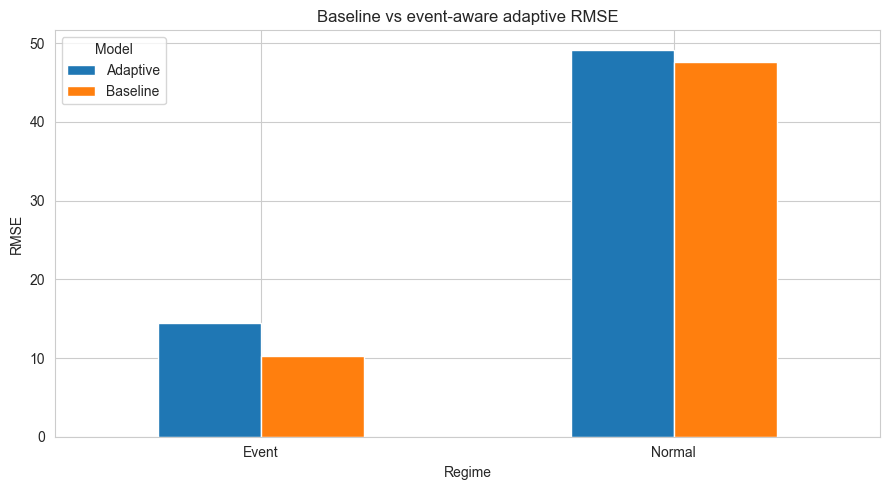

In [68]:
# ============================================================
# 11. ADAPTIVE MODEL: NORMAL VS EVENT PERFORMANCE
# ============================================================
adaptive_eval = test[["target_next", "event_flag"]].copy()
adaptive_eval["baseline"] = test_pred
adaptive_eval["adaptive"] = adaptive_pred

rows = []
for regime_value, regime_name in [(0, "Normal"), (1, "Event")]:
    g = adaptive_eval[adaptive_eval["event_flag"] == regime_value]
    if len(g) == 0:
        continue
    for model_name, col in [("Baseline", "baseline"), ("Adaptive", "adaptive")]:
        m = regression_metrics(g["target_next"], g[col])
        rows.append({
            "Regime": regime_name,
            "Model": model_name,
            **m,
            "N": len(g)
        })

adaptive_regime_results = pd.DataFrame(rows)
display(adaptive_regime_results)

pivot_rmse = adaptive_regime_results.pivot(index="Regime", columns="Model", values="RMSE")
ax = pivot_rmse.plot(kind="bar", figsize=(9, 5))
ax.set_title("Baseline vs event-aware adaptive RMSE")
ax.set_ylabel("RMSE")
ax.set_xlabel("Regime")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 12. Requirement III — Conformal prediction

We use split conformal prediction on a **calibration set** that is kept separate from the final test set.

For a point forecast `ŷ`, the interval is:

`[ŷ - q, ŷ + q]`

where `q` is obtained from the empirical distribution of absolute calibration residuals.

The interval is data-driven and does not assume Gaussian forecast errors.


In [69]:
# ============================================================
# 12. SPLIT CONFORMAL PREDICTION
# ============================================================
# Use the validation set as the calibration set.
cal_pred = model.predict(val[feature_cols])
cal_abs_resid = np.abs(val["target_next"].to_numpy() - cal_pred)

# Finite-sample conformal quantile.
n_cal = len(cal_abs_resid)
q_level = np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal
q_level = min(1.0, q_level)
q_hat = np.quantile(cal_abs_resid, q_level, method="higher")

lower = test_pred - q_hat
upper = test_pred + q_hat

conformal_df = pd.DataFrame({
    "actual": test["target_next"].to_numpy(),
    "forecast": test_pred,
    "lower": lower,
    "upper": upper,
    "event_flag": test["event_flag"].to_numpy()
}, index=test.index)

coverage = np.mean(
    (conformal_df["actual"] >= conformal_df["lower"]) &
    (conformal_df["actual"] <= conformal_df["upper"])
)
mean_width = np.mean(conformal_df["upper"] - conformal_df["lower"])

print("Conformal residual quantile:", round(float(q_hat), 3))
print("Target coverage:", f"{1-ALPHA:.1%}")
print("Observed test coverage:", f"{coverage:.1%}")
print("Mean interval width:", round(float(mean_width), 3))


Conformal residual quantile: 79.988
Target coverage: 90.0%
Observed test coverage: 96.3%
Mean interval width: 159.976


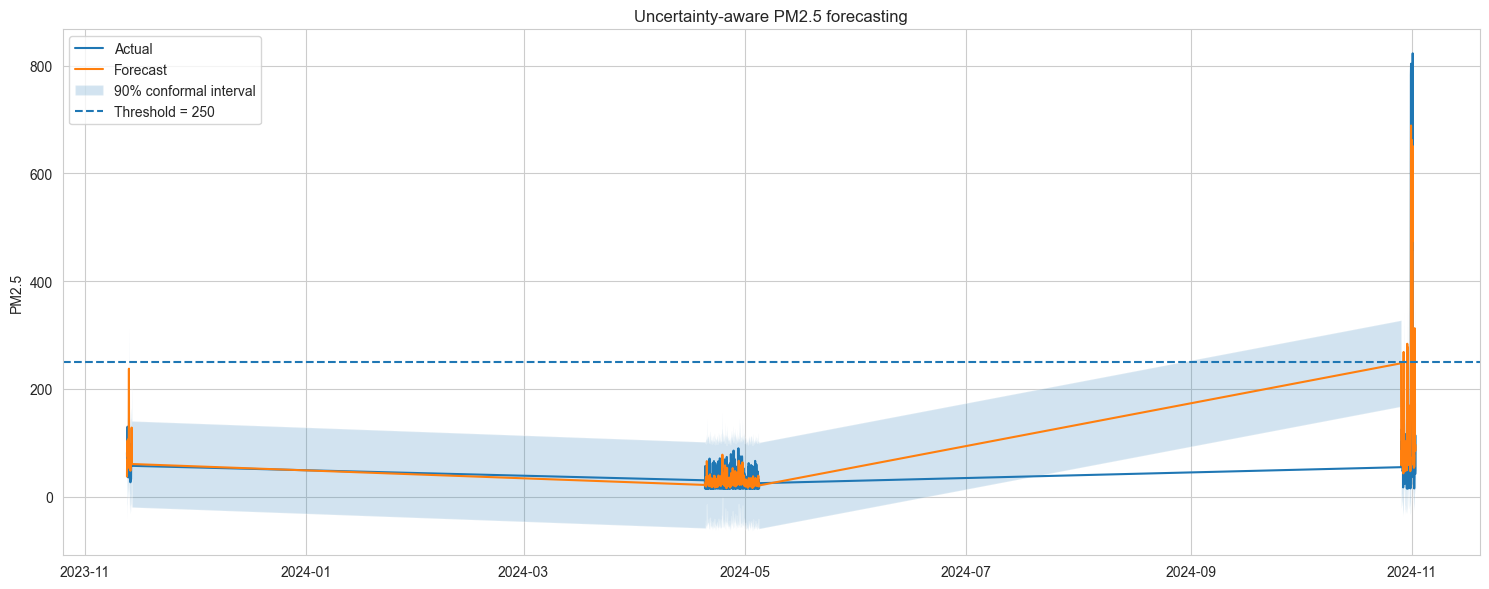

In [70]:
# ============================================================
# 13. CONFORMAL FORECAST VISUALIZATION
# ============================================================
plot_df = conformal_df.tail(min(500, len(conformal_df)))

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(plot_df.index, plot_df["actual"], label="Actual")
ax.plot(plot_df.index, plot_df["forecast"], label="Forecast")
ax.fill_between(
    plot_df.index,
    plot_df["lower"],
    plot_df["upper"],
    alpha=0.20,
    label=f"{1-ALPHA:.0%} conformal interval"
)
ax.axhline(THRESHOLD, linestyle="--", label=f"Threshold = {THRESHOLD:g}")
ax.set_title("Uncertainty-aware PM2.5 forecasting")
ax.set_ylabel("PM2.5")
ax.legend()
plt.tight_layout()
plt.show()


# 14. Pollution-threshold exceedance risk

A conservative operational risk flag is produced when the conformal interval reaches or exceeds the selected pollution threshold.

For a production deployment, a richer probabilistic calibration method can be added. For the capstone, the notebook explicitly distinguishes:

- **Point forecast**
- **Prediction interval**
- **Threshold risk flag**

so the uncertainty output is not confused with a deterministic forecast.


,Count
Risk,
Low,472
High,17
Watch,3


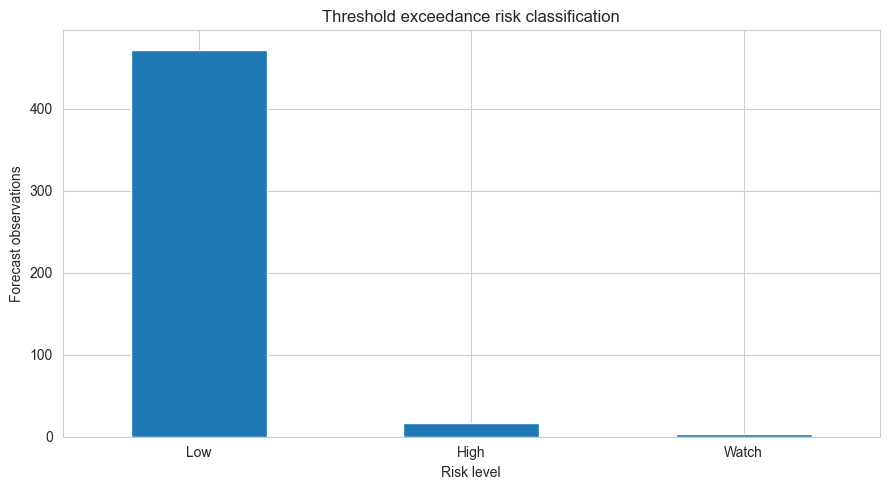

In [71]:
# ============================================================
# 14. THRESHOLD EXCEEDANCE RISK
# ============================================================
conformal_df["threshold"] = THRESHOLD
conformal_df["upper_exceeds_threshold"] = conformal_df["upper"] >= THRESHOLD
conformal_df["point_exceeds_threshold"] = conformal_df["forecast"] >= THRESHOLD
conformal_df["risk_level"] = np.select(
    [
        conformal_df["point_exceeds_threshold"],
        conformal_df["upper_exceeds_threshold"]
    ],
    [
        "High",
        "Watch"
    ],
    default="Low"
)

risk_summary = conformal_df["risk_level"].value_counts().rename_axis("Risk").to_frame("Count")
display(risk_summary)

fig, ax = plt.subplots(figsize=(9, 5))
risk_summary["Count"].plot(kind="bar", ax=ax)
ax.set_title("Threshold exceedance risk classification")
ax.set_ylabel("Forecast observations")
ax.set_xlabel("Risk level")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [72]:
# ============================================================
# 15. COMBINED FINAL RESULTS TABLE
# ============================================================
final_summary = pd.DataFrame([
    {
        "Experiment": "XGBoost baseline",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "MAPE_%": baseline_metrics["MAPE_%"]
    },
    {
        "Experiment": "Event-aware adaptive XGBoost",
        "MAE": adaptive_metrics["MAE"],
        "RMSE": adaptive_metrics["RMSE"],
        "MAPE_%": adaptive_metrics["MAPE_%"]
    }
])

display(final_summary)

uncertainty_summary = pd.DataFrame([{
    "Target coverage": 1 - ALPHA,
    "Observed coverage": coverage,
    "Mean interval width": mean_width,
    "Threshold": THRESHOLD,
    "Watch/High fraction": np.mean(conformal_df["risk_level"] != "Low")
}])

display(uncertainty_summary)


,Experiment,MAE,RMSE,MAPE_%
0,XGBoost baseline,23.206163,47.380832,61.884156
1,Event-aware adaptive XGBoost,23.192170,48.889519,60.870434


,Target coverage,Observed coverage,Mean interval width,Threshold,Watch/High fraction
0,0.9,0.963415,159.975558,250.0,0.04065


# 16. Supervisor presentation visualizations

Recommended figures for the final report/presentation:

1. Synthetic vs real CPCB PM2.5 distributions.
2. Synthetic vs CPCB forecasting error table, for all four models (SARIMA, Prophet, XGBoost, LSTM).
3. Normal vs event RMSE.
4. Baseline vs adaptive event-model RMSE.
5. Actual vs point forecast with conformal interval.
6. Threshold and exceedance-risk timeline.
7. Event-detection timeline.
8. A final dashboard combining current regime, forecast, interval and risk.

The notebook above creates the core figures without fabricating CPCB results.


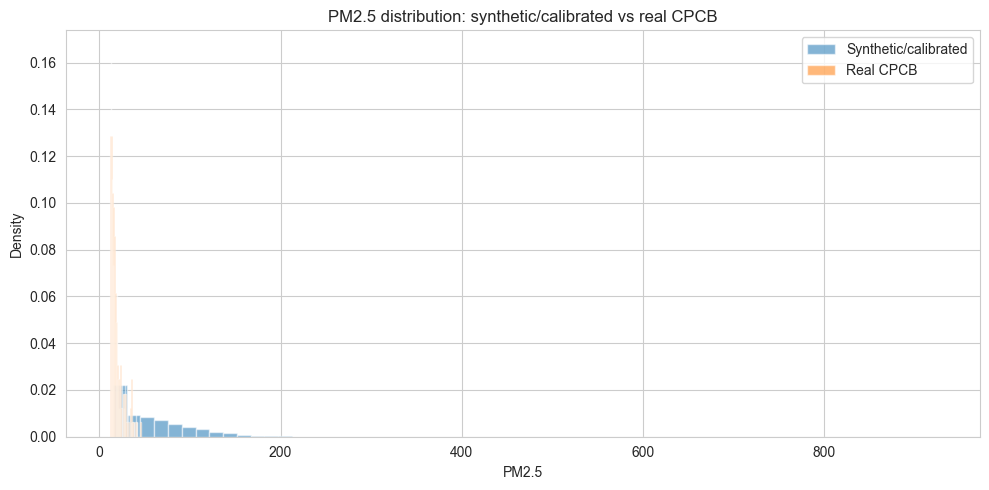

In [73]:
# ============================================================
# 16. OPTIONAL SYNTHETIC VS CPCB DISTRIBUTION
# ============================================================
if cpcb is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(synthetic[TARGET].dropna(), bins=60, alpha=0.55, density=True, label="Synthetic/calibrated")
    ax.hist(cpcb_hourly[TARGET].dropna(), bins=60, alpha=0.55, density=True, label="Real CPCB")
    ax.set_title("PM2.5 distribution: synthetic/calibrated vs real CPCB")
    ax.set_xlabel("PM2.5")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Distribution comparison will appear automatically after CPCB data are supplied.")


## 16a. Multi-model forecast overlays — synthetic data

One panel per model (XGBoost, SARIMA, Prophet, LSTM), actual vs forecast over its own test window. SARIMA/Prophet panels are daily; XGBoost/LSTM panels are hourly — axis ranges differ accordingly, which is expected given the resolution note in Section 6.


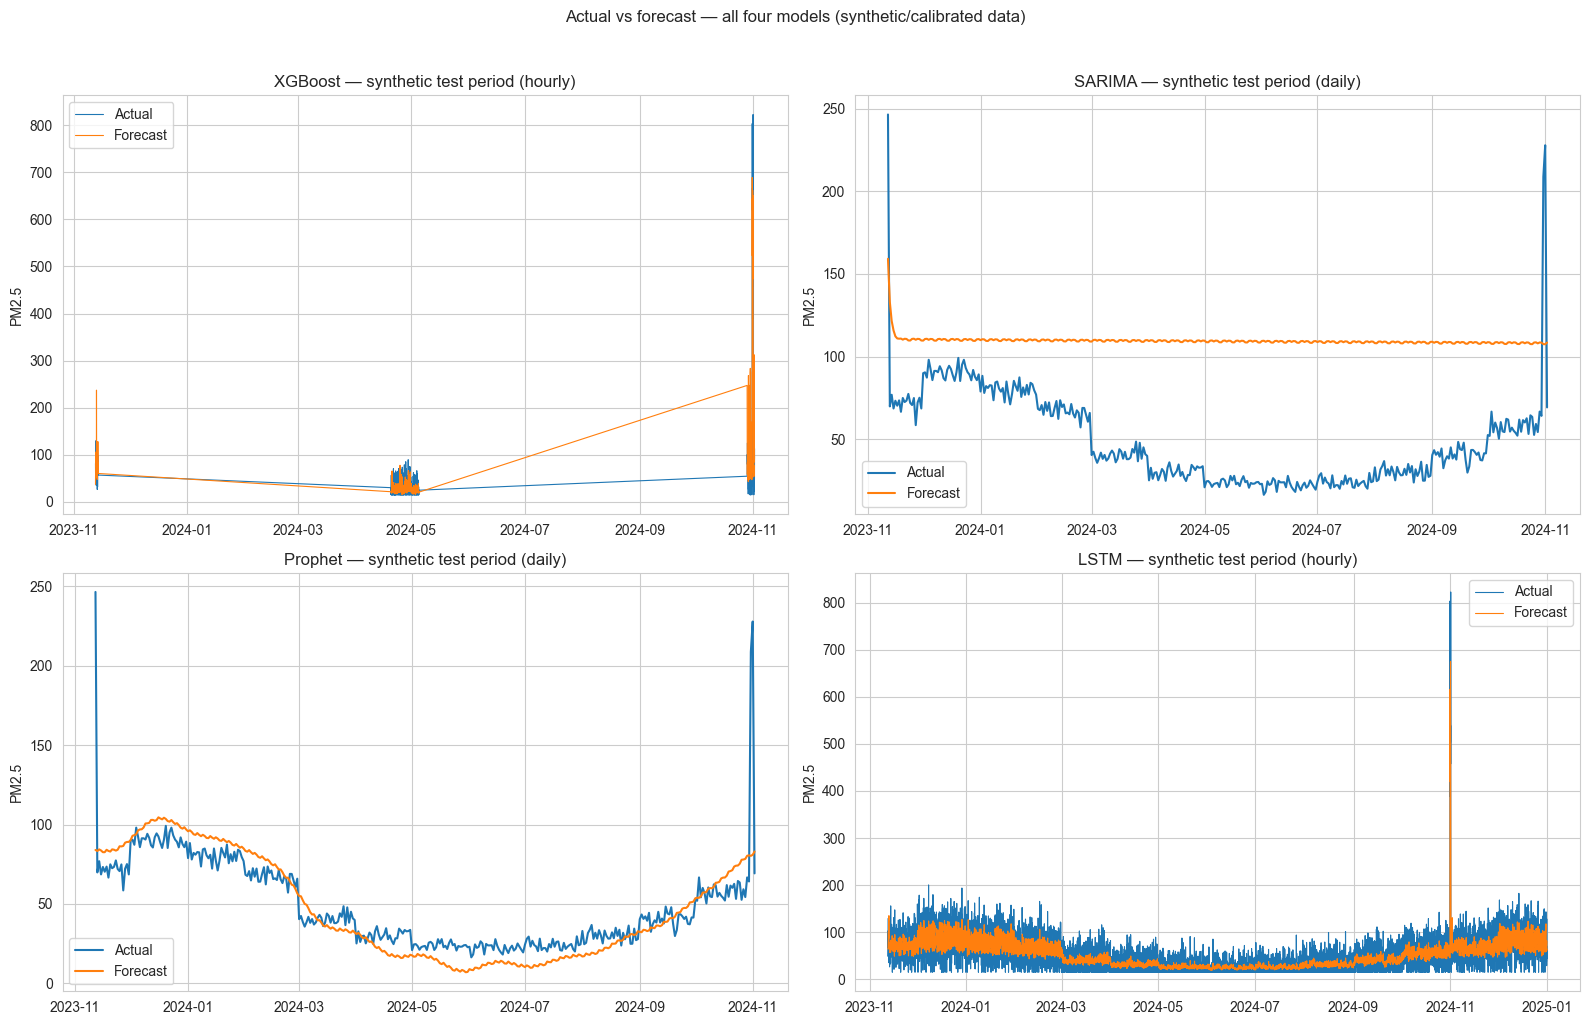

In [74]:
# ============================================================
# 16a. MULTI-MODEL FORECAST OVERLAY — SYNTHETIC DATA
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# XGBoost (hourly)
ax = axes[0]
ax.plot(eval_df.index, eval_df["target_next"], label="Actual", linewidth=0.8)
ax.plot(eval_df.index, eval_df["prediction"], label="Forecast", linewidth=0.8)
ax.set_title("XGBoost — synthetic test period (hourly)")
ax.set_ylabel("PM2.5")
ax.legend()

# SARIMA (daily)
ax = axes[1]
if sarima_metrics is not None:
    ax.plot(sarima_daily_test.index, sarima_daily_test.values, label="Actual")
    ax.plot(sarima_pred.index, sarima_pred.values, label="Forecast")
    ax.legend()
else:
    ax.text(0.5, 0.5, "SARIMA unavailable", ha="center", va="center", transform=ax.transAxes)
ax.set_title("SARIMA — synthetic test period (daily)")
ax.set_ylabel("PM2.5")

# Prophet (daily)
ax = axes[2]
if prophet_metrics is not None:
    ax.plot(sarima_daily_test.index, sarima_daily_test.values, label="Actual")
    ax.plot(prophet_pred.index, prophet_pred.values, label="Forecast")
    ax.legend()
else:
    ax.text(0.5, 0.5, "Prophet unavailable", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Prophet — synthetic test period (daily)")
ax.set_ylabel("PM2.5")

# LSTM (hourly)
ax = axes[3]
if lstm_metrics is not None:
    ax.plot(lstm_actual.index, lstm_actual.values, label="Actual", linewidth=0.8)
    ax.plot(lstm_pred.index, lstm_pred.values, label="Forecast", linewidth=0.8)
    ax.legend()
else:
    ax.text(0.5, 0.5, "LSTM unavailable", ha="center", va="center", transform=ax.transAxes)
ax.set_title("LSTM — synthetic test period (hourly)")
ax.set_ylabel("PM2.5")

fig.suptitle("Actual vs forecast — all four models (synthetic/calibrated data)", y=1.02)
plt.tight_layout()
plt.savefig("figures/synthetic_all_models_overlay.png", dpi=150, bbox_inches="tight") if Path("figures").exists() else None
plt.show()


## 16b. Multi-model forecast overlays — real CPCB data

Same layout as 16a, but on the real CPCB test window. A model shows "unavailable" if it was skipped in Section 9 (e.g. too little CPCB history to fit safely) — no CPCB numbers are fabricated to fill a panel.


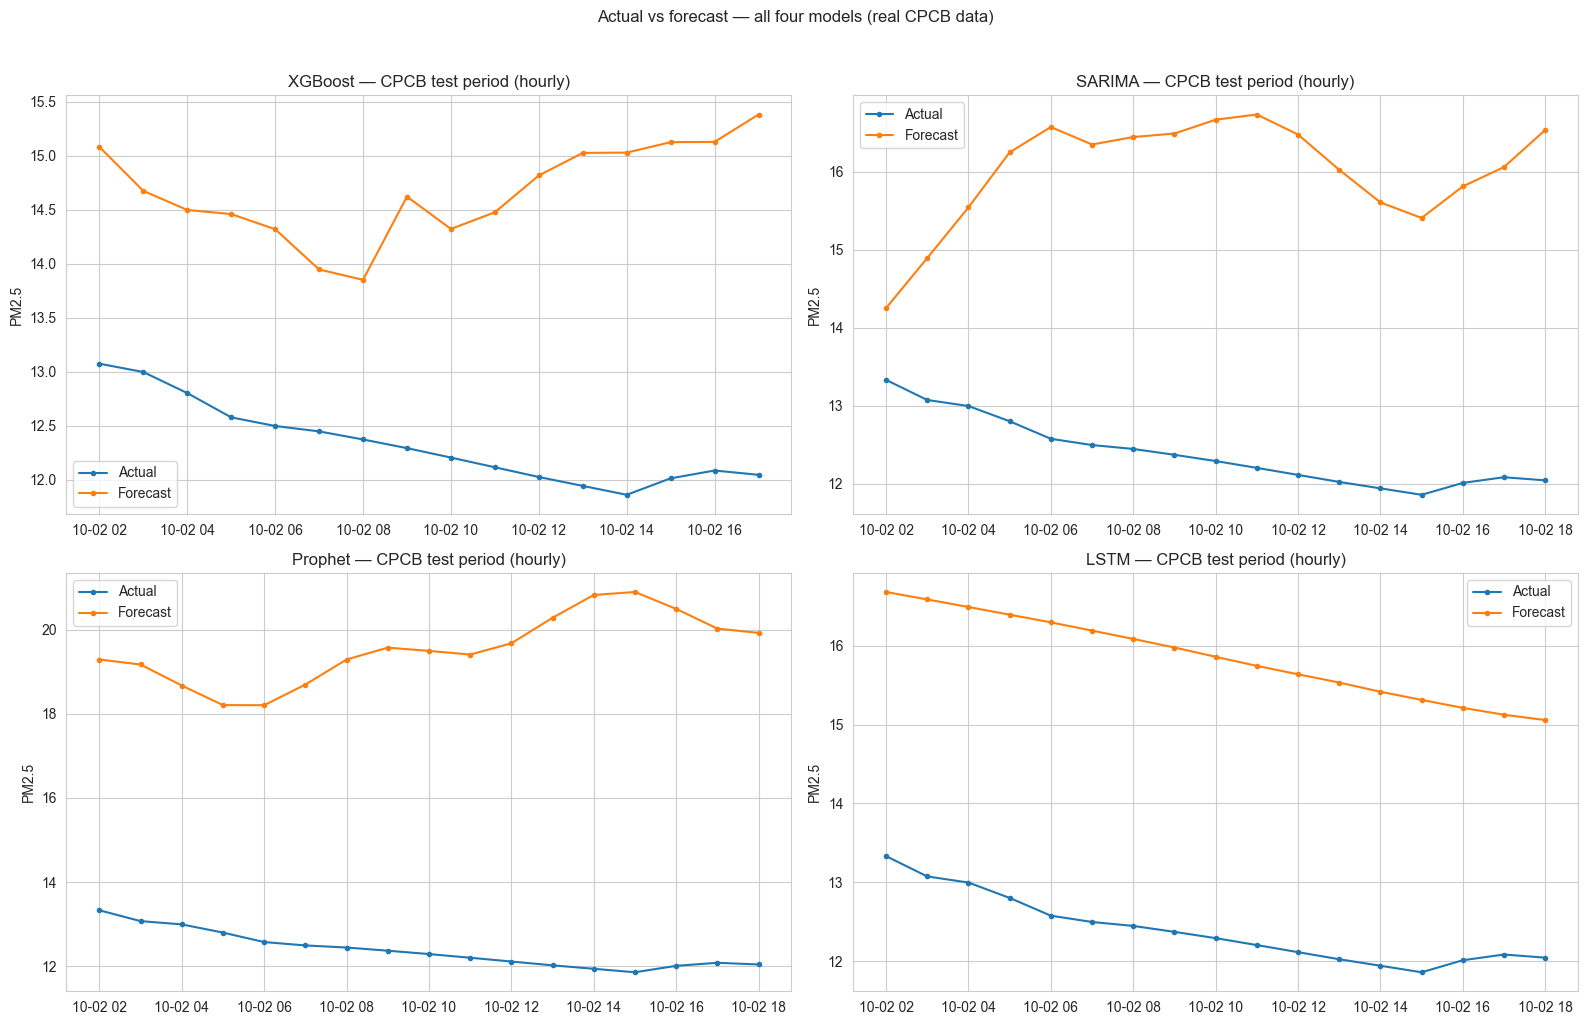

In [75]:
# ============================================================
# 16b. MULTI-MODEL FORECAST OVERLAY — REAL CPCB DATA
# ============================================================
if cpcb is None:
    print("CPCB overlay will appear automatically after CPCB data are supplied.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    # XGBoost
    ax = axes[0]
    ax.plot(c_test.index, c_test["target_next"], label="Actual", marker="o", markersize=3)
    ax.plot(c_test.index, c_pred, label="Forecast", marker="o", markersize=3)
    ax.set_title("XGBoost — CPCB test period (hourly)")
    ax.set_ylabel("PM2.5")
    ax.legend()

    # SARIMA
    ax = axes[1]
    if cpcb_sarima_metrics is not None:
        ax.plot(cs_test.index, cs_test.values, label="Actual", marker="o", markersize=3)
        ax.plot(cs_pred.index, cs_pred.values, label="Forecast", marker="o", markersize=3)
        ax.legend()
    else:
        ax.text(0.5, 0.5, "SARIMA unavailable\n(insufficient CPCB history)", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("SARIMA — CPCB test period (hourly)")
    ax.set_ylabel("PM2.5")

    # Prophet
    ax = axes[2]
    if cpcb_prophet_metrics is not None:
        ax.plot(cp_test.index, cp_test.values, label="Actual", marker="o", markersize=3)
        ax.plot(cp_pred.index, cp_pred.values, label="Forecast", marker="o", markersize=3)
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Prophet unavailable", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Prophet — CPCB test period (hourly)")
    ax.set_ylabel("PM2.5")

    # LSTM
    ax = axes[3]
    if cpcb_lstm_metrics is not None:
        ax.plot(cl_actual.index, cl_actual.values, label="Actual", marker="o", markersize=3)
        ax.plot(cl_pred.index, cl_pred.values, label="Forecast", marker="o", markersize=3)
        ax.legend()
    else:
        ax.text(0.5, 0.5, "LSTM unavailable\n(too little data for the window)", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("LSTM — CPCB test period (hourly)")
    ax.set_ylabel("PM2.5")

    fig.suptitle("Actual vs forecast — all four models (real CPCB data)", y=1.02)
    plt.tight_layout()
    plt.savefig("figures/cpcb_all_models_overlay.png", dpi=150, bbox_inches="tight") if Path("figures").exists() else None
    plt.show()


## 16c. Metrics dashboard — MAE / RMSE / MAPE across all models and datasets

One bar-chart panel per metric, all four models grouped by dataset (Synthetic vs Real CPCB where available). This is the single figure to use if the presentation only has room for one model-comparison slide.


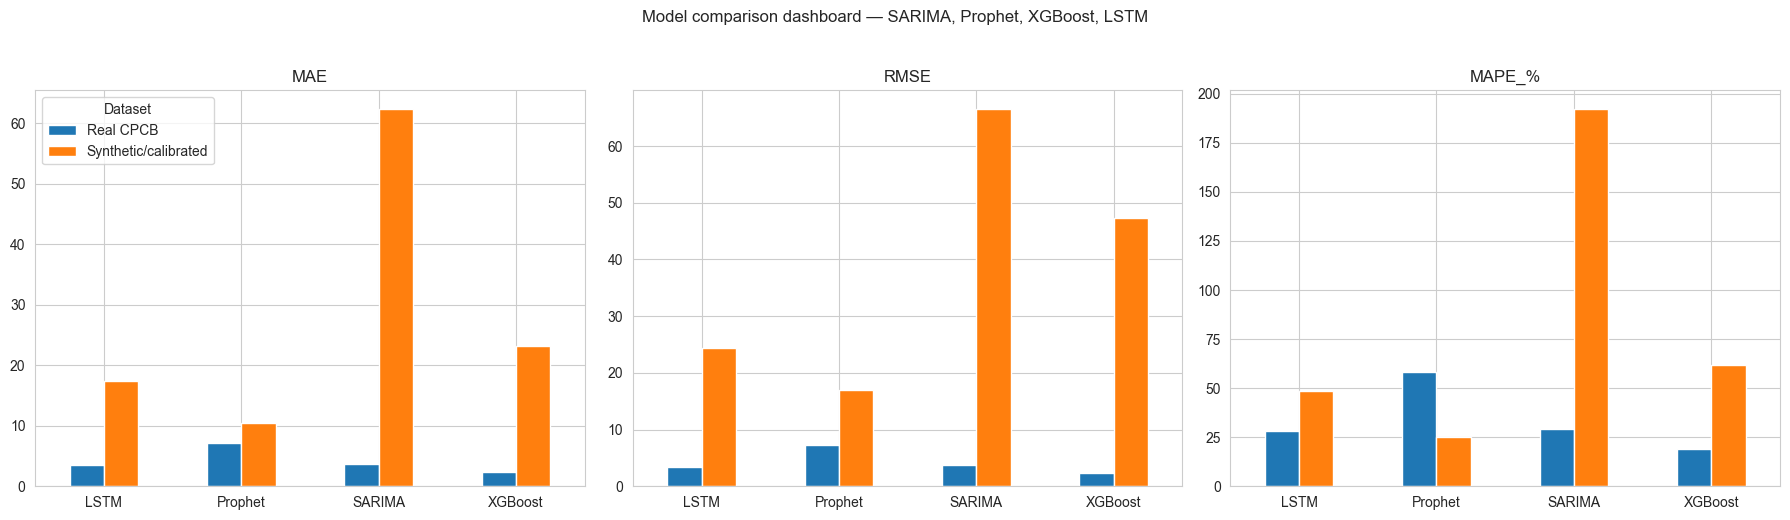

In [76]:
# ============================================================
# 16c. METRICS DASHBOARD — ALL MODELS, ALL METRICS
# ============================================================
if cpcb is not None and full_model_comparison is not None:
    dash_df = pd.DataFrame(combined_rows)
else:
    dash_df = pd.DataFrame(synthetic_rows)
    dash_df["Dataset"] = "Synthetic/calibrated"

metrics_to_plot = ["MAE", "RMSE", "MAPE_%"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5))
if len(metrics_to_plot) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_to_plot):
    pivot = dash_df.pivot(index="Model", columns="Dataset", values=metric)
    pivot.plot(kind="bar", ax=ax, legend=(ax is axes[0]))
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Model comparison dashboard — SARIMA, Prophet, XGBoost, LSTM", y=1.03)
plt.tight_layout()
plt.savefig("figures/model_metrics_dashboard.png", dpi=150, bbox_inches="tight") if Path("figures").exists() else None
plt.show()


# 17. Export results

The following cell saves the principal tables so they can be inserted into the report.


In [77]:
# ============================================================
# 17. EXPORT RESULTS
# ============================================================
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

normal_event_results.to_csv(RESULTS_DIR / "normal_vs_event_baseline.csv")
adaptive_comparison.to_csv(RESULTS_DIR / "baseline_vs_adaptive.csv")
adaptive_regime_results.to_csv(RESULTS_DIR / "adaptive_regime_results.csv")
conformal_df.to_csv(RESULTS_DIR / "conformal_forecasts.csv")
risk_summary.to_csv(RESULTS_DIR / "threshold_risk_summary.csv")
synthetic_model_comparison.to_csv(RESULTS_DIR / "synthetic_four_model_comparison.csv")

if cpcb is not None:
    cpcb_model_comparison.to_csv(RESULTS_DIR / "cpcb_four_model_comparison.csv")
    full_model_comparison.to_csv(RESULTS_DIR / "synthetic_vs_cpcb_four_models.csv")

print("Results exported to:", RESULTS_DIR.resolve())


Results exported to: M:\capston_project_2\project\results


# 18. Research interpretation checklist

Before presenting to the supervisor, report the following:

### I. Real sensor-data validation
- Number of real CPCB observations.
- Date range and station coverage.
- Synthetic vs CPCB distribution comparison.
- MAE / RMSE / MAPE on each dataset.
- Whether model ranking changes between synthetic and real data.

### II. Event-aware adaptive forecasting
- Number of detected event observations/windows.
- Baseline model performance during normal and event periods.
- Adaptive model performance during normal and event periods.
- Relative improvement during extreme events.

### III. Uncertainty-aware forecasting
- Conformal coverage target.
- Observed empirical coverage.
- Mean prediction-interval width.
- Number/fraction of threshold watch/high forecasts.
- Example pollution-spike timeline showing forecast + interval + threshold.

### Important scientific caution
Do not claim that the conformal interval is valid on CPCB data merely because it was calibrated on synthetic data. Calibrate and evaluate uncertainty on the same real-data experimental design when sufficient CPCB observations are available.


# Appendix — integration note

This notebook combines the original baseline air-quality forecasting workflow with the enhanced Capstone II workflow. The baseline section is retained first, followed by CPCB validation, event-aware adaptive forecasting, conformal prediction, threshold-risk analysis, visualizations, exports, and the research interpretation checklist.